## CTG Signal Analysis Guide


**This notebook is intended to help apply a tool that analyzes CTG signals, extracting features such as baseline, variability, and decelerations, to assist in the classification of CTGs as hypoxic or non-hypoxic. Following these guidelines ensures correct loading, processing, and feature extraction from CTG signals.**

For the use of this code, it is essential to adjust the paths to the directories where the CTG database to be analyzed is located.
Likewise, the database must be in the following format:

1. For each CTG, there must be a `.dat` file and a `.hea` file with the same name. This name will serve as the CTG identifier, so it is recommended, to avoid possible errors, that it be numeric.
2. The `.dat` file will contain the FHR and UC information, which must be labeled as “FHR” and “UC” respectively.
3. The `.hea` file contains clinical information about the delivery, such as:
   `["ph", "bdecf", "pco2", "be", "apgar1", "apgar5", "gest. weeks", "weight", "sex", "age", "gravidity", "parity", "diabetes", "hypertension", "preeclampsia", "liq. praecox", "pyrexia", "meconium", "presentation", "induced", "I. stage", "noProgress", "CK/KP", "II. stage", "deliv. type"]`
   The use of these category names must be preserved for proper detection.

This format was designed to maintain compatibility with the public CTU-CHB database, as it is one of the most widely used databases for the study of fetal hypoxia.
The mentioned database can be downloaded from the following link: …

Data related to the doctors’ responses to the conducted survey can be found at this link: ***. In addition, the path to the folder where these data are stored must also be adjusted.

### 1.- Import the necessary libraries

In [1]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

%load_ext autoreload
%autoreload 2

import sys
import os
import re

ruta_base = ".."
sys.path.append(os.path.abspath(ruta_base))

from read_data.read_data import *
from matplotlib import pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import confusion_matrix

### 2.- Set the directory names

These parameters indicate:
- **path_folder_data**: The path where CTG files are located.
- **cut_time_read_data**: Defines how much signal is read from the file (upper limit).
- **cut_time_preprocessing**: Defines how much of that signal is kept for preprocessing and feature extraction.

Important: Ensure that the CTG files (.dat and .hea) are stored in the specified folder and correctly named, since filenames are used as CTG identifiers.

In [2]:
path_folder_public_data = 'data/db_public/'
path_folder_private_data = 'data/db_12O/'

# Si se va a calcular la curva de correlación es recomendable no tomar tiempos mayores de 30 min
cut_time_read_data = 30 # 4 horas (Max size is 90 min = 21600 elems)
cut_time_preprocessing = 30 # min

### 3.- Load and preprocess the data

The following command loads all CTG records, verifies their structure, and applies basic cleaning procedures, trimming excessively long signals.

During this step, the program reports any skipped files that do not meet the expected structure.

In [29]:
## cut_time en minutos

data = read_data(path_folder_public_data, cut_time = cut_time_read_data, freq = 4, private_db=False)
# data = read_data(path_folder_private_data, cut_time = cut_time_read_data, freq = 4, private_db=True)

There are 1108 files in this directory
Loading: 1220.dat
Loading: 1220.hea
Loading: 1234.dat
Loading: 1234.hea
Loading: 1208.dat
Loading: 1208.hea
Loading: 1022.dat
Loading: 1022.hea
Loading: 1036.dat
Loading: 1036.hea
Loading: 1156.dat
Loading: 1156.hea
Loading: 1142.dat
Loading: 1142.hea
Loading: 1195.dat
Loading: 1195.hea
Loading: 1181.dat
Loading: 1181.hea
Loading: 1354.dat
Loading: 1354.hea
Loading: 1432.dat
Loading: 1432.hea
Loading: 1426.dat
Loading: 1426.hea
Loading: 1340.dat
Loading: 1340.hea
Loading: 1368.dat
Loading: 1368.hea
Loading: 1397.dat
Loading: 1397.hea
Loading: 1383.dat
Loading: 1383.hea
Loading: 1382.dat
Loading: 1382.hea
Loading: 1396.dat
Loading: 1396.hea
Loading: 1369.dat
Loading: 1369.hea
Loading: 1427.dat
Loading: 1427.hea
Loading: 1341.dat
Loading: 1341.hea
Loading: 1355.dat
Loading: 1355.hea
Loading: 1433.dat
Loading: 1433.hea
Loading: 1180.dat
Loading: 1180.hea
Loading: 1194.dat
Loading: 1194.hea
Loading: 1143.dat
Loading: 1143.hea
Loading: 1157.dat
Loading

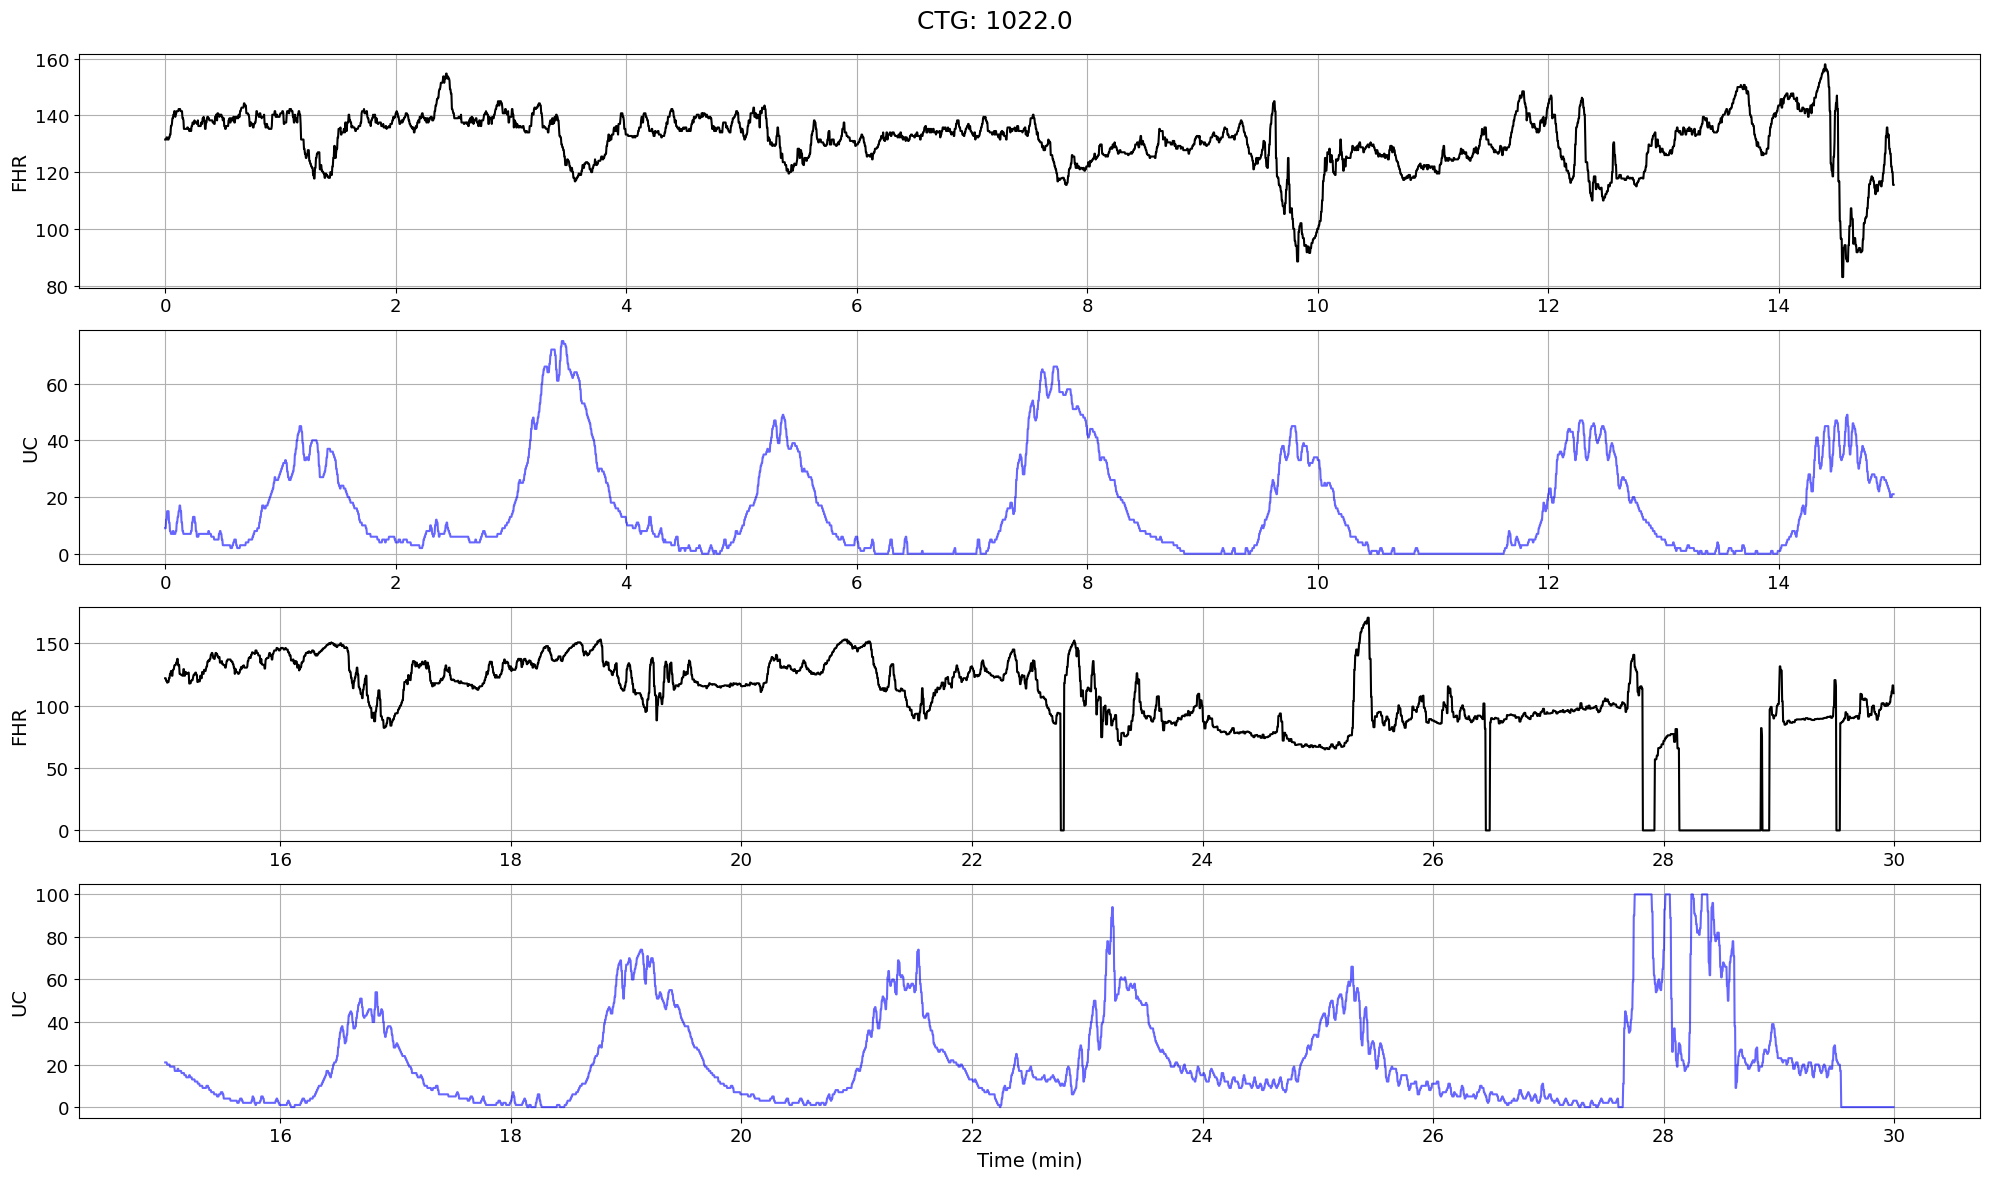

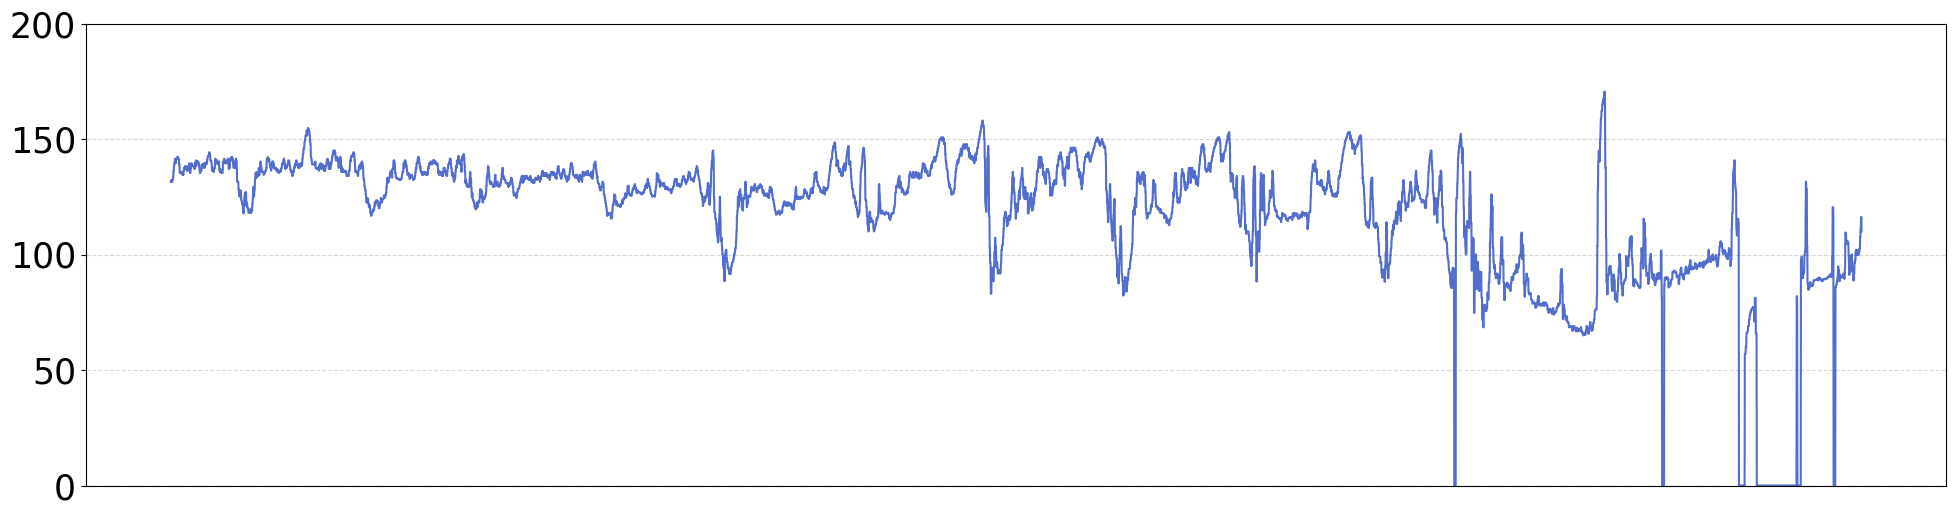

In [30]:
data.ctgs[3].plot_ctg()
data.ctgs[3].plot_fhr(save_name = "fhr_sin_preprocesar.pdf")

Next, we preprocess all CTGs to clean the signals, handle artifacts and missing values, and trim each signal to retain only the most relevant portion.

In [31]:
# cut_time esta en  MINUTOS
data.preprocess_ctgs(rules_type = 'FIGO', cut_time = cut_time_preprocessing, rm_tail_nan=True)

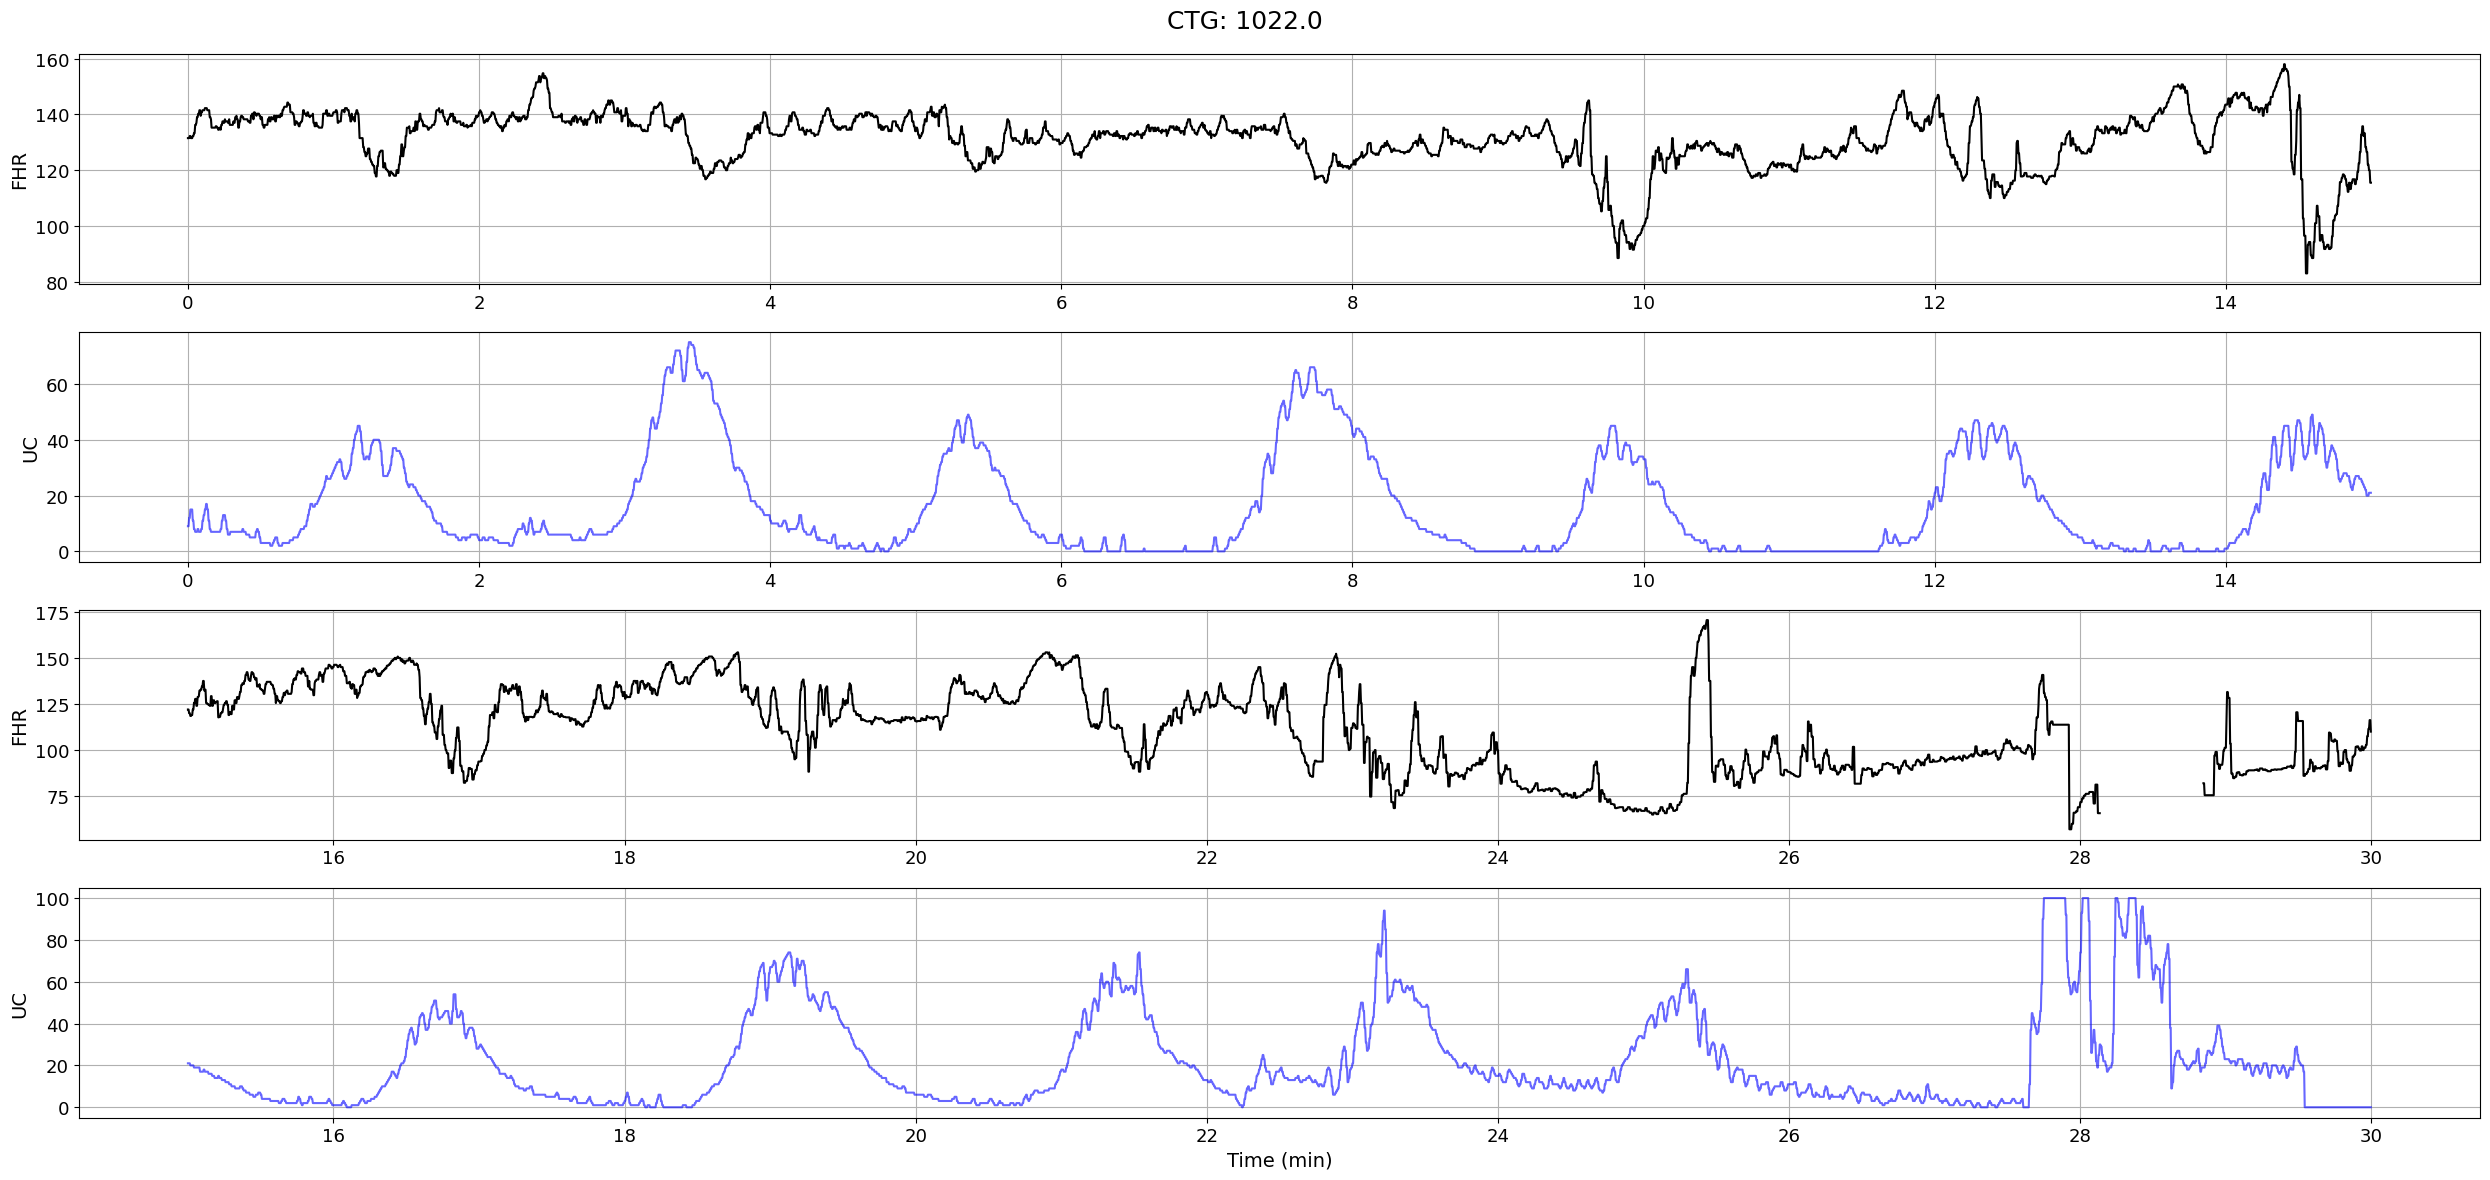

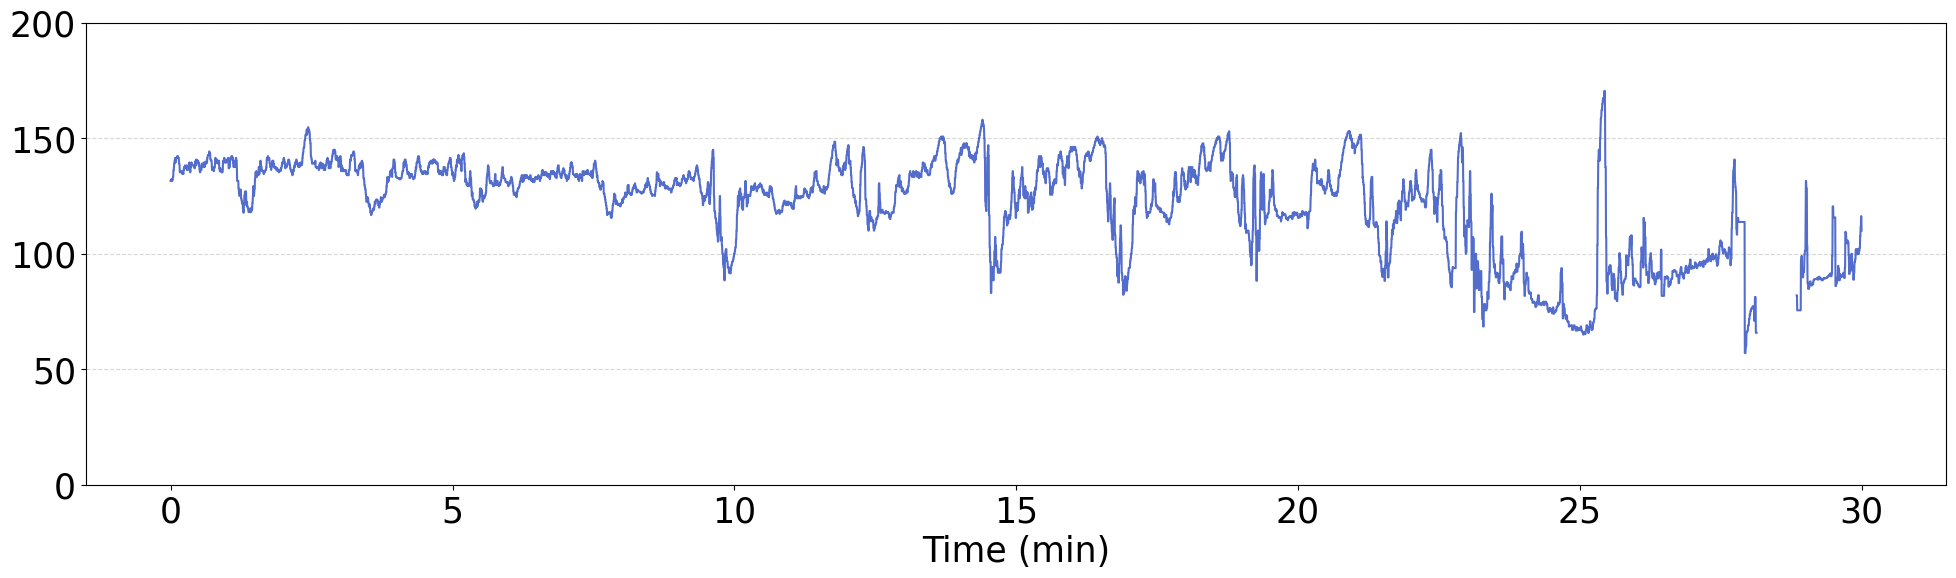

In [88]:
data.ctgs[3].plot_ctg()
data.ctgs[3].plot_fhr(title_eje_x = True, save_name = "fhr_preprocesada.pdf")

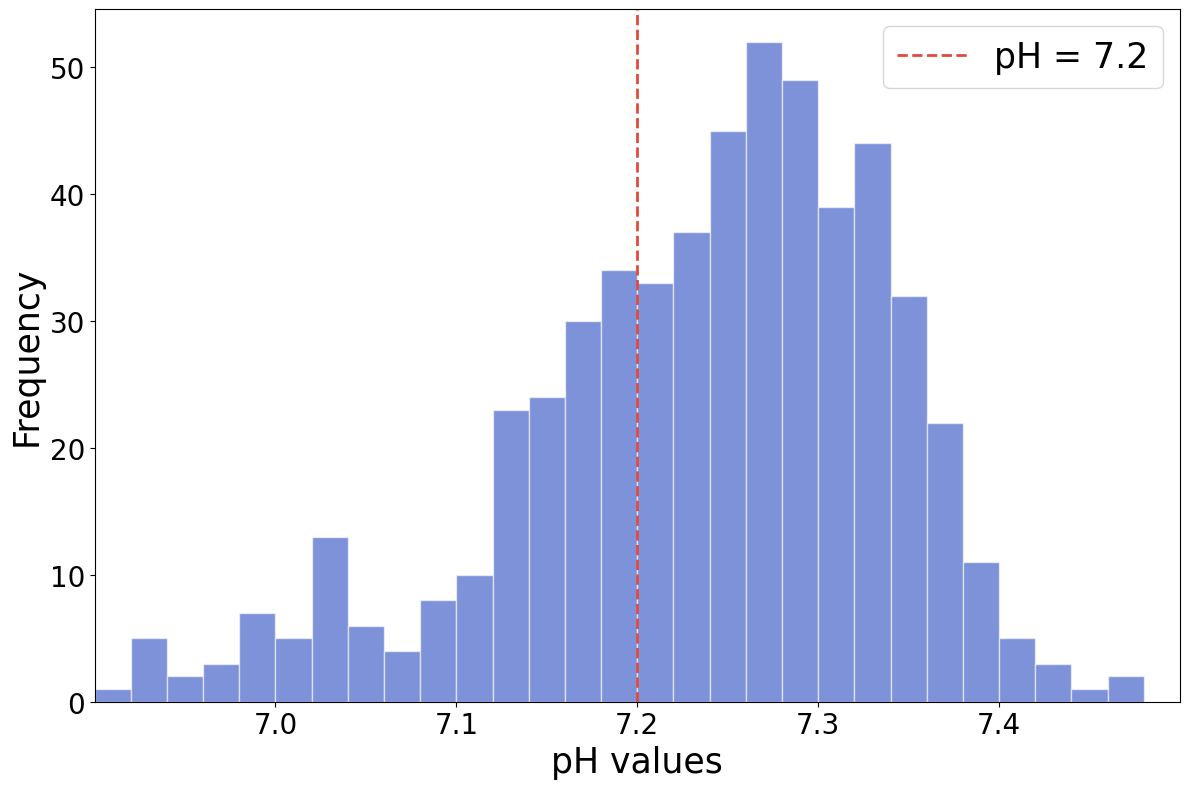

In [116]:
# Histograma del ph
data.ph_histogram()

### 4.- Example of CTG trace analysis

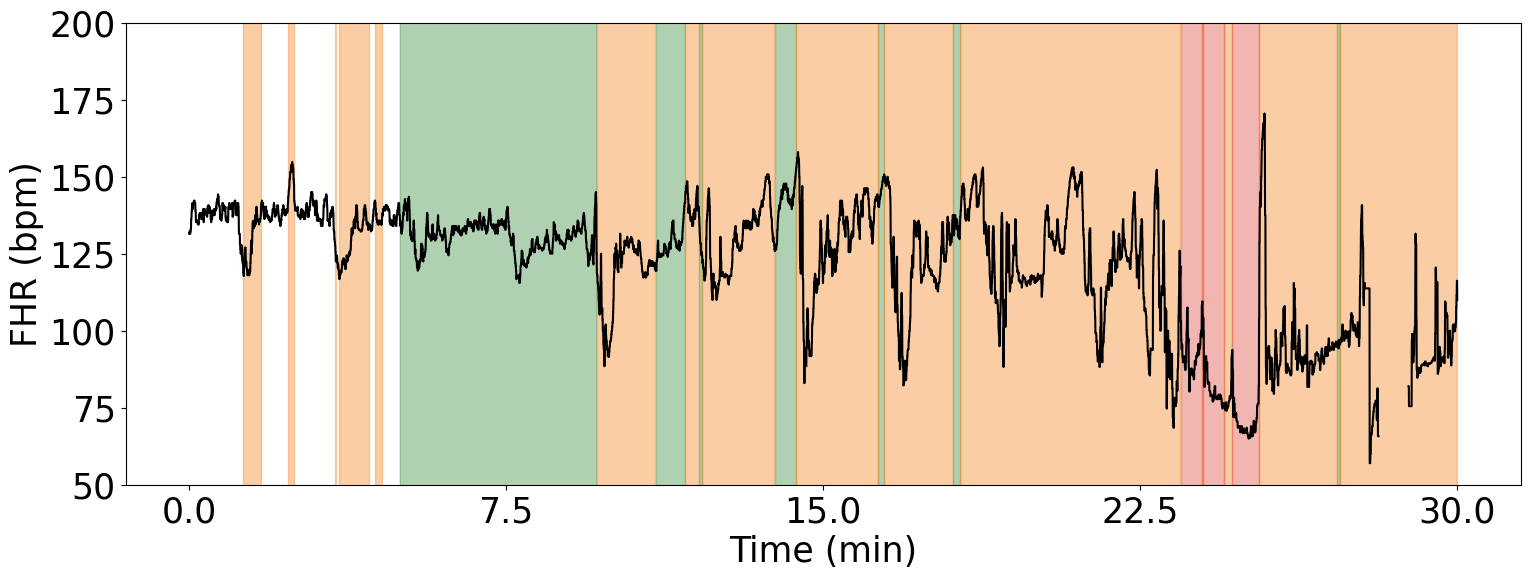

0       NaN
1       NaN
2       NaN
3       NaN
4       NaN
       ... 
7195    1.0
7196    1.0
7197    1.0
7198    1.0
7199    1.0
Length: 7200, dtype: float64

In [80]:
ctg_num_3 = data.ctgs[3]
ctg_num_3.apply_rules_FIGO()

We can analyze an individual CTG by applying the FIGO rules to evaluate it. In the following plots, we can see, using colors, the correlation of different segments of the CTG with potential hypoxia: green for normal, orange for suspicious, and red for pathological.

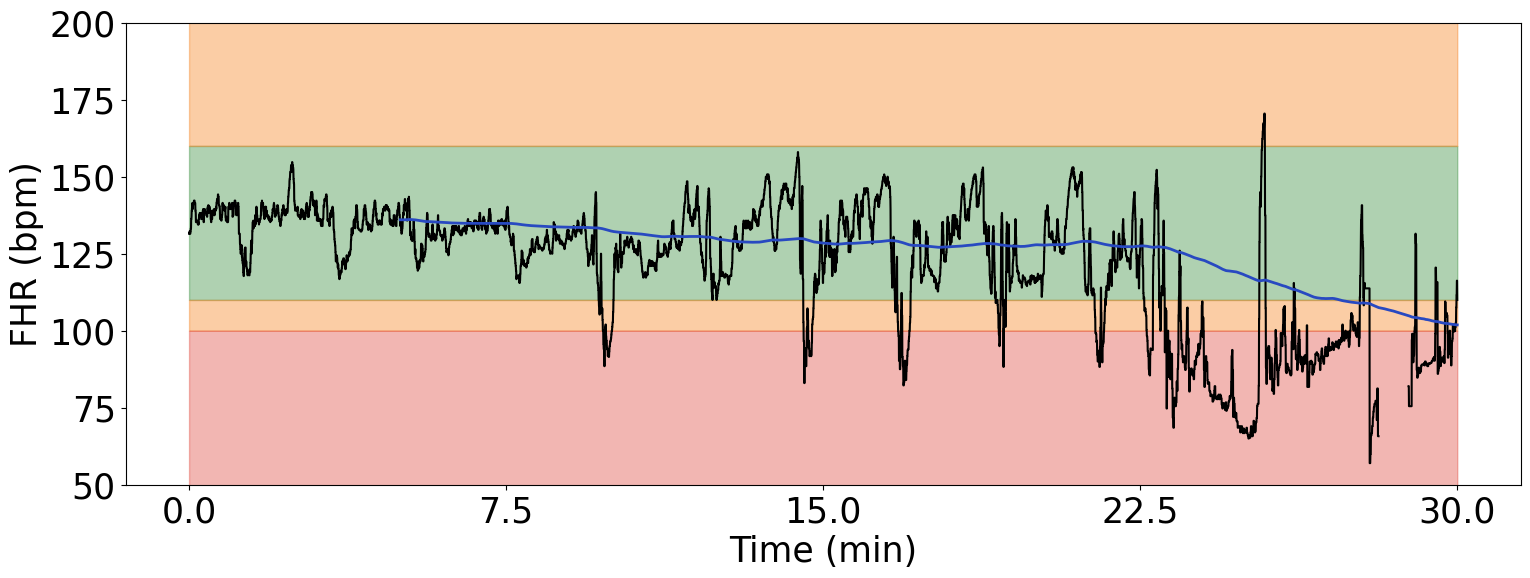

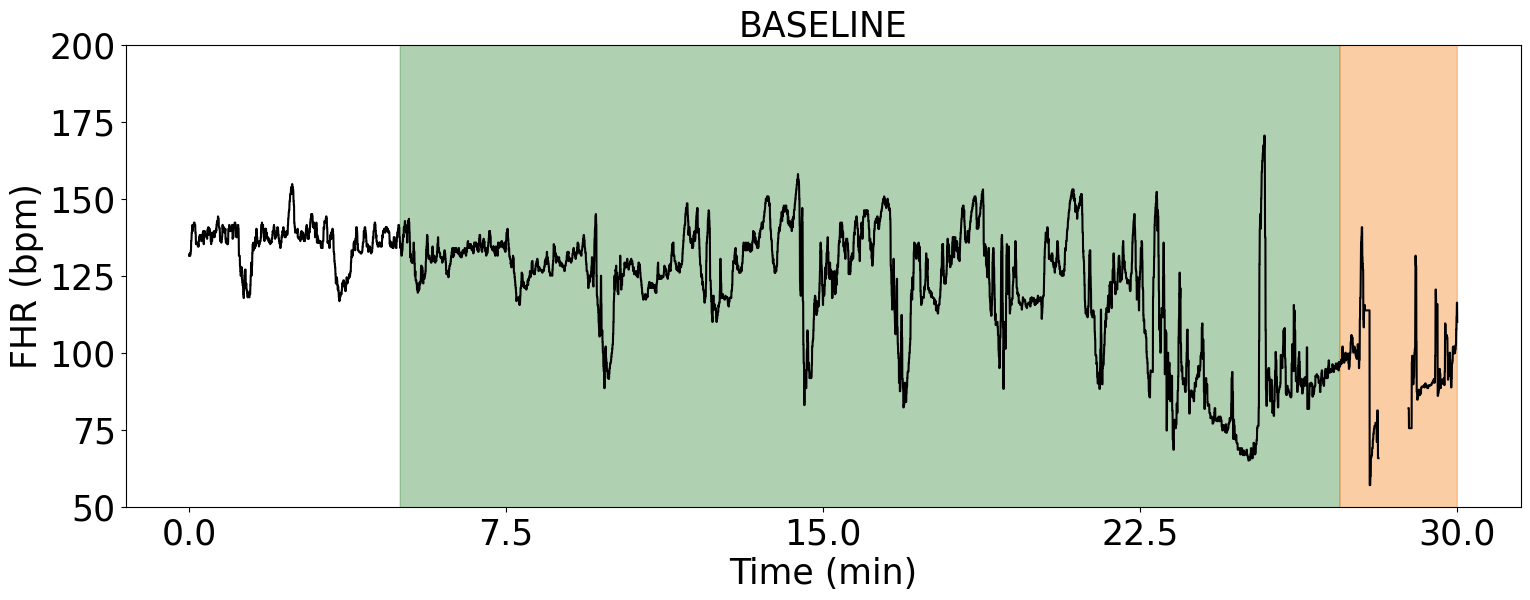

In [81]:
ctg_num_3._get_baseline_graph()
ctg_num_3._baseline_graph()

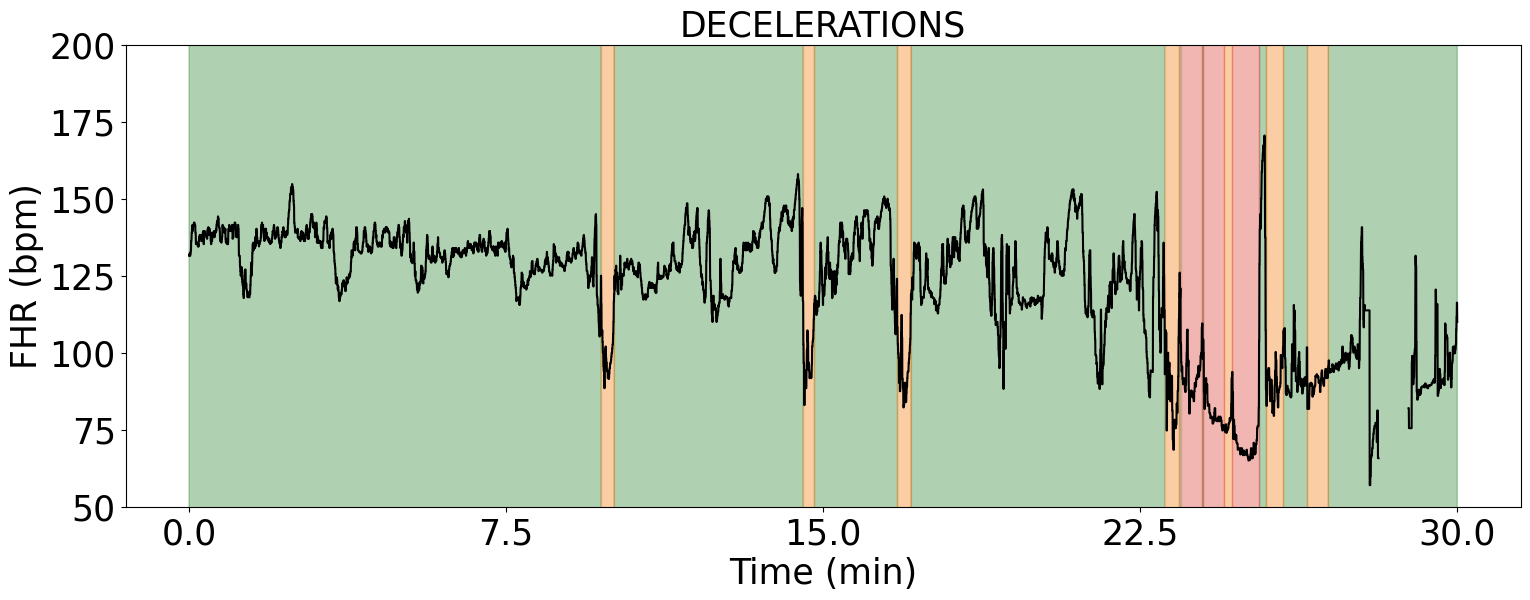

In [82]:
ctg_num_3._decelerations_graph()

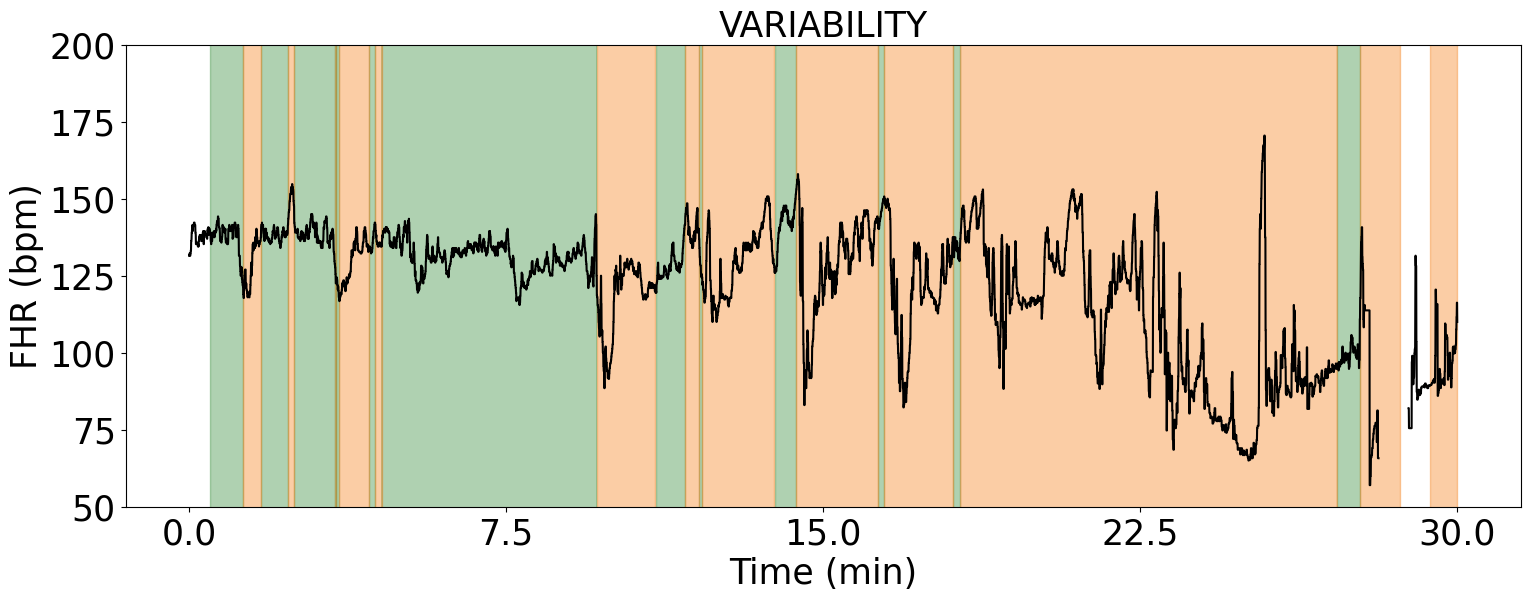

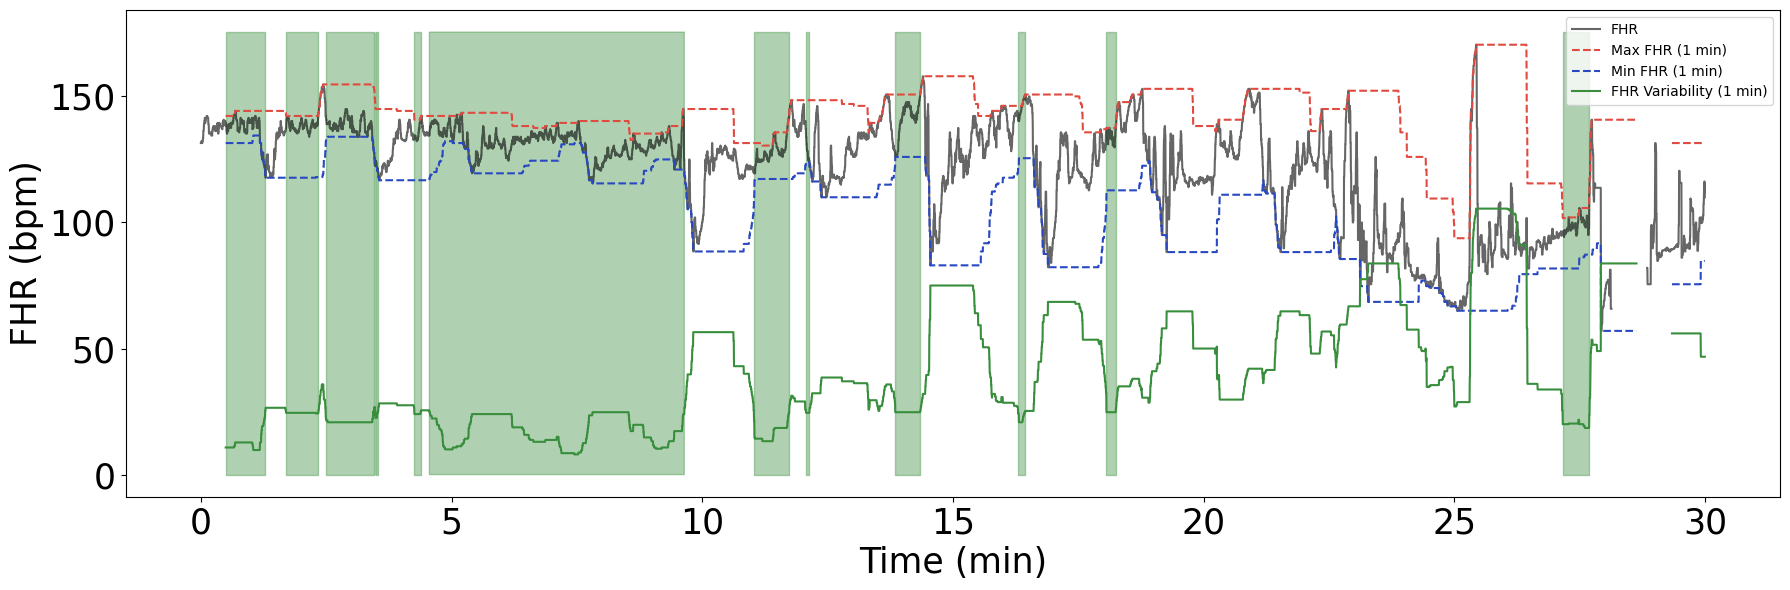

In [83]:
ctg_num_3._variability_graph()
ctg_num_3._get_variability_graph()

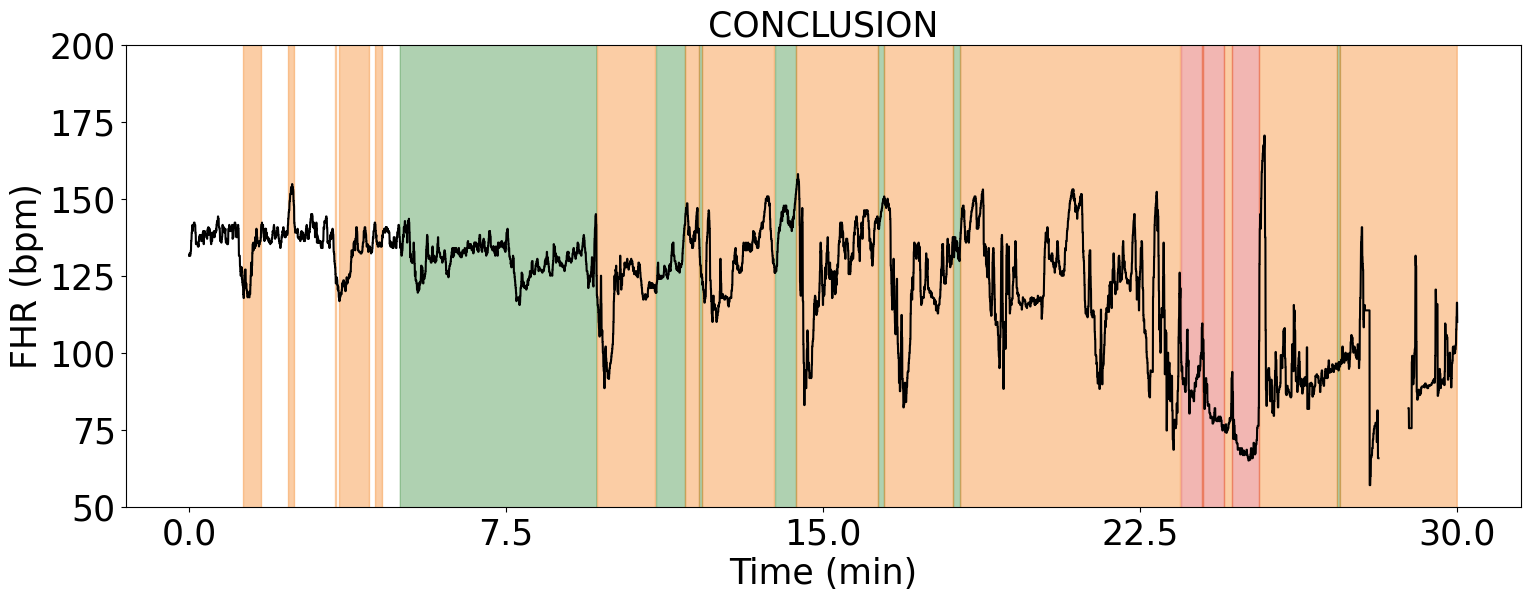

In [84]:
ctg_num_3._conclusion_graph()

CONTRACTION 1
CONTRACTION 2
CONTRACTION 3
CONTRACTION 4
CONTR GRAPH 1
CONTR GRAPH 2
CONTR GRAPH 3


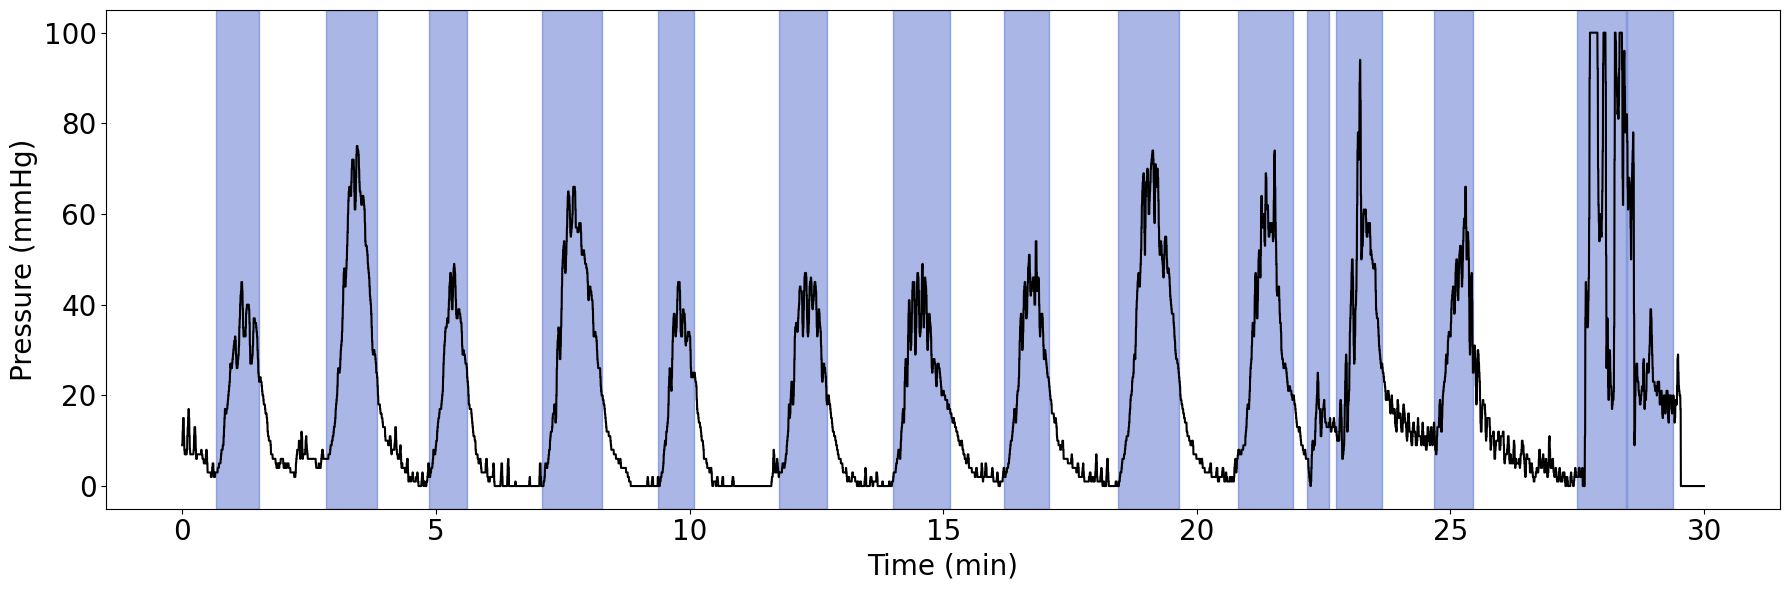

In [72]:
ctg_num_3.get_contractions_graph()

### 5.- Automatic model ROC curve

We can assess the automatic FIGO-based classification model using an ROC (Receiver Operating Characteristic) curve:

The rules will be applied following the guidelines:  FIGO
552/552 

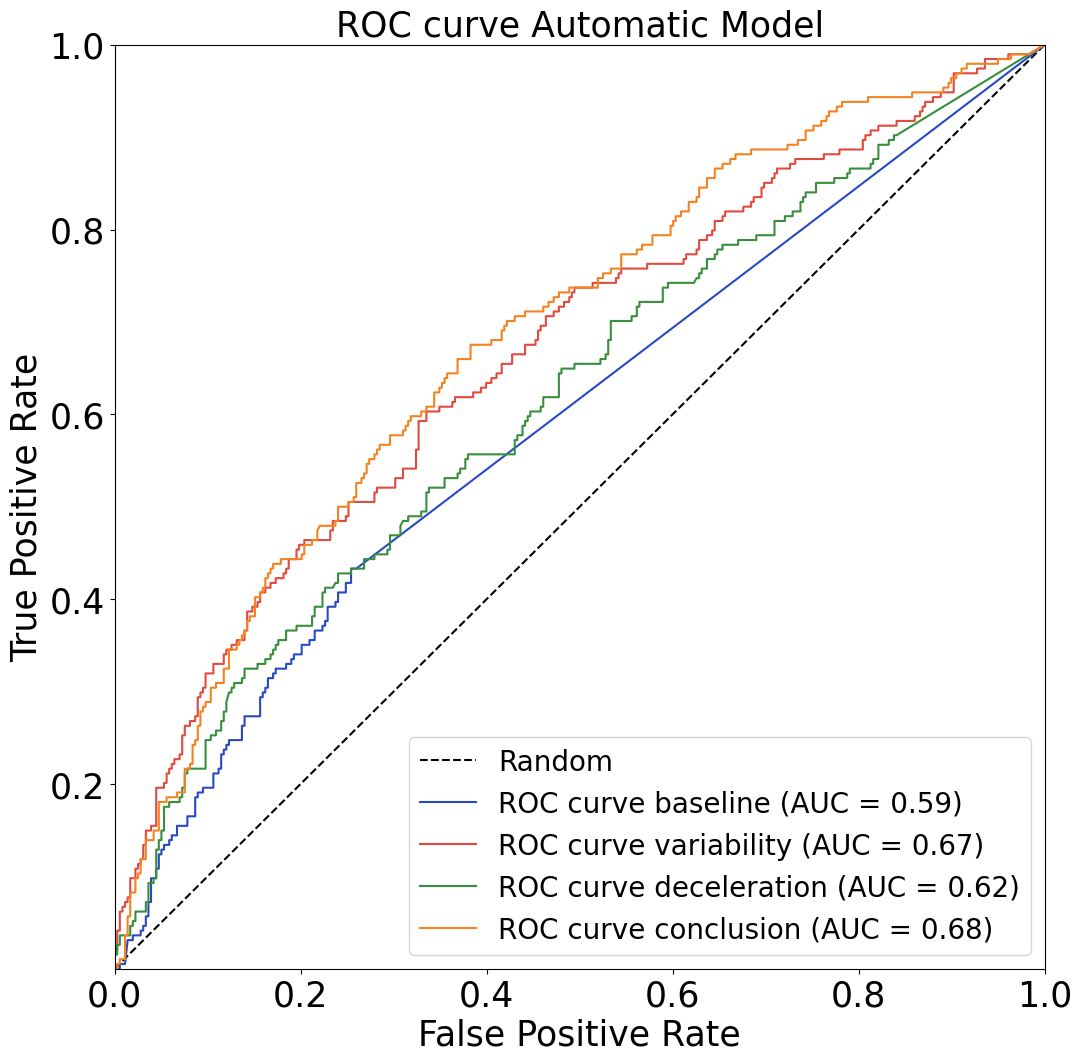

In [74]:
data.get_roc_curves(title='ROC curve Automatic Model')

This step plots sensitivity vs. specificity and calculates the AUC (Area Under the Curve) — a measure of diagnostic performance.

### 6.- Load survey data and define ground truth (only for public database)

In this step, we (1) import the data obtained from the physician survey, (2) process it to convert the responses into a numeric format suitable for analysis, and (3) extract the true labels for comparison.

In [47]:
# Load CSV 
df = pd.read_csv("data/medical_survey/Hipoxia_Fetal2025-10-13_04_43_01.csv", encoding='utf-8')

# Filter only classification columns
classification_cols = [col for col in df.columns if "¿Cómo clasifica este RCTG?" in col]

# Create a dictionary to rename columns
new_name_cols = {}
for col in classification_cols:
    match = re.search(r'(\d+)/\d+', col) 
    if match:
        new_name_cols[col] = int(match.group(1)) 

# Apply the new names
classifications = df[classification_cols].rename(columns=new_name_cols)

# Clean and convert responses to numeric values
#classifications = classifications.applymap(lambda x: str(x).strip().lower())
classifications = classifications.map(lambda x: str(x).strip().lower())
classifications = classifications.replace({
    'normal': 0,
    'sospechosa': 0.5,
    'patológica': 1,
    'patologica': 1
})

# Drop rows with NaN
clasificaciones_1 = classifications.iloc[:, 0:20]
classifications = clasificaciones_1.iloc[:, 0:20].loc[:, list(range(1, 21))].apply(pd.to_numeric, errors='coerce').dropna()

In [48]:
# Define the ground truth
ph = [7.33, 7.32, 7.12, 7.19, 7.2, 7.2, 7.22, 7.37, 7.0, 
      7.31, 7.13, 7.15, 7.27, 7.24, 7.3, 7.18, 6.95, 7.3, 
      7.27, 7.08]

ground_truth = [0 if valor >= 7.20 else 1 for valor in ph]

ground_truth

[0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1]

In [49]:
# Create df_ctg for the survey data
survey_ids = [1309, 1340, 1161, 1288, 1283, 1412, 1473, 2041, 1017, 1150, 1400, 1249, 1450, 1113, 1378, 1154, 1359, 1366, 1332, 2043]

survey_data = DF_CTG(freq=4)
for id in survey_ids:
    ctg = data.get_ctg_by_id(id)
    survey_data.add_ctg(ctg)

### 7.- Define ROC curve: experts vs. automatic model

Compute ROC curves for both groups.

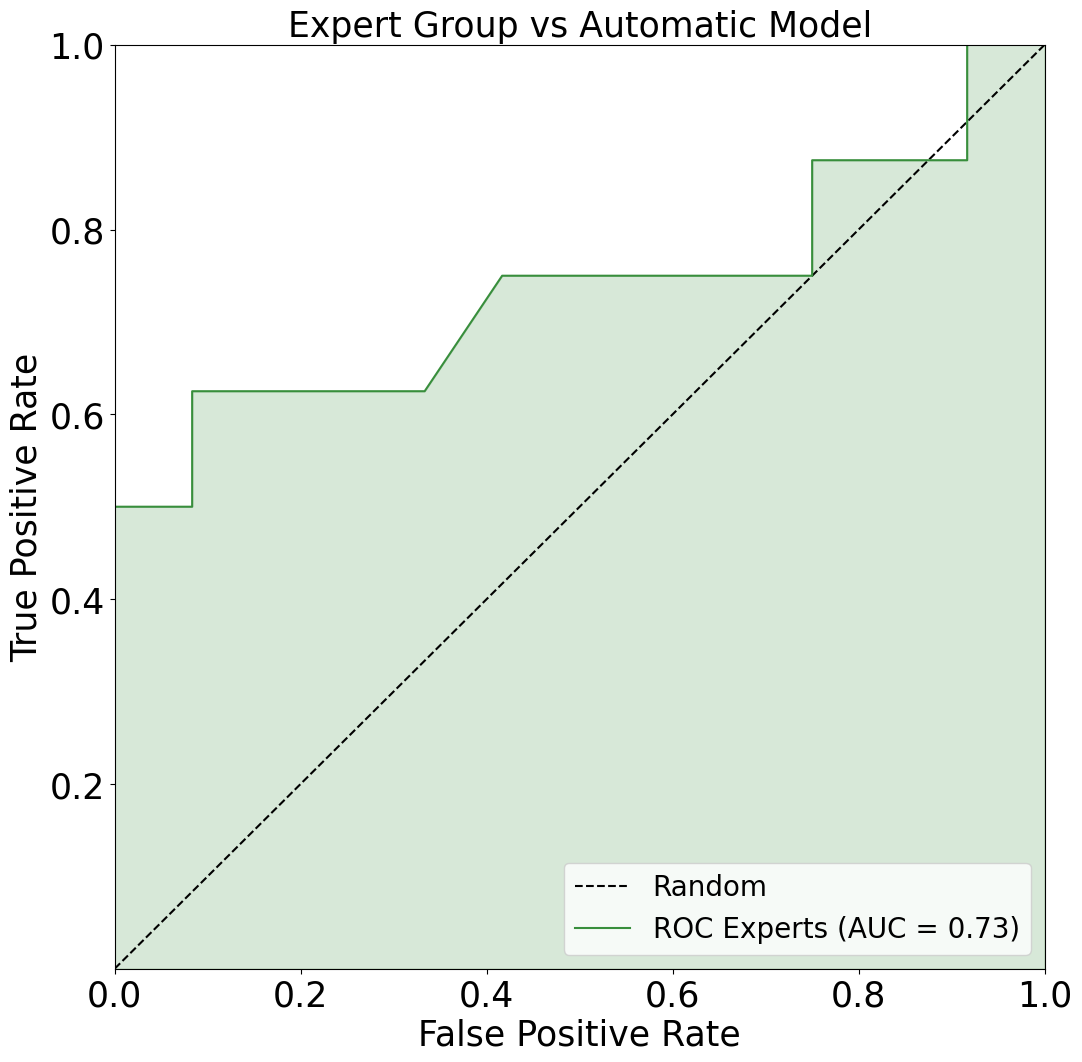

In [ ]:
# Automatic model
survey_data.get_roc_curves(only_conclusion = True, title = 'ROC curve Experts vs Automatic Model')

# Medical model
# plt.figure(figsize=(7, 6))  
# plt.plot([0,1], [0,1], linestyle='--', color='black', label="Random")
ctg_scores = classifications.transpose().mean(axis=1).values  

fpr, tpr, thresholds = roc_curve(ground_truth, ctg_scores)
roc_auc = auc(fpr, tpr)

plt.title('Expert Group vs Automatic Model',  fontsize=25)
plt.xlabel("False Positive Rate",  fontsize=25)
plt.ylabel("True Positive Rate",  fontsize=25)

plt.fill_between(fpr, 0, tpr, color="#388E3C", alpha=0.2)
plt.plot(fpr, tpr, color = '#388E3C', label=f'ROC Experts (AUC = {roc_auc:.2f})')

# plt.legend(loc='lower right', fontsize=15)
plt.legend(
        loc="lower right",  # Posición fija dentro del recuadro
        ncol=1,  # Una sola columna
        fontsize=20,
    )

# Aumentar tamaño de los ticks
plt.xticks(fontsize=25)
plt.yticks(np.arange(0.2, 1.2, 0.2), fontsize=25)

plt.xlim(0, 1)
plt.ylim(0, 1)

plt.savefig("roc_medicos_aut.pdf", format="pdf", bbox_inches='tight')

### 8.- ROC curve for each physician

This final step visualizes each expert’s diagnostic performance individually, helping assess inter-observer variability.

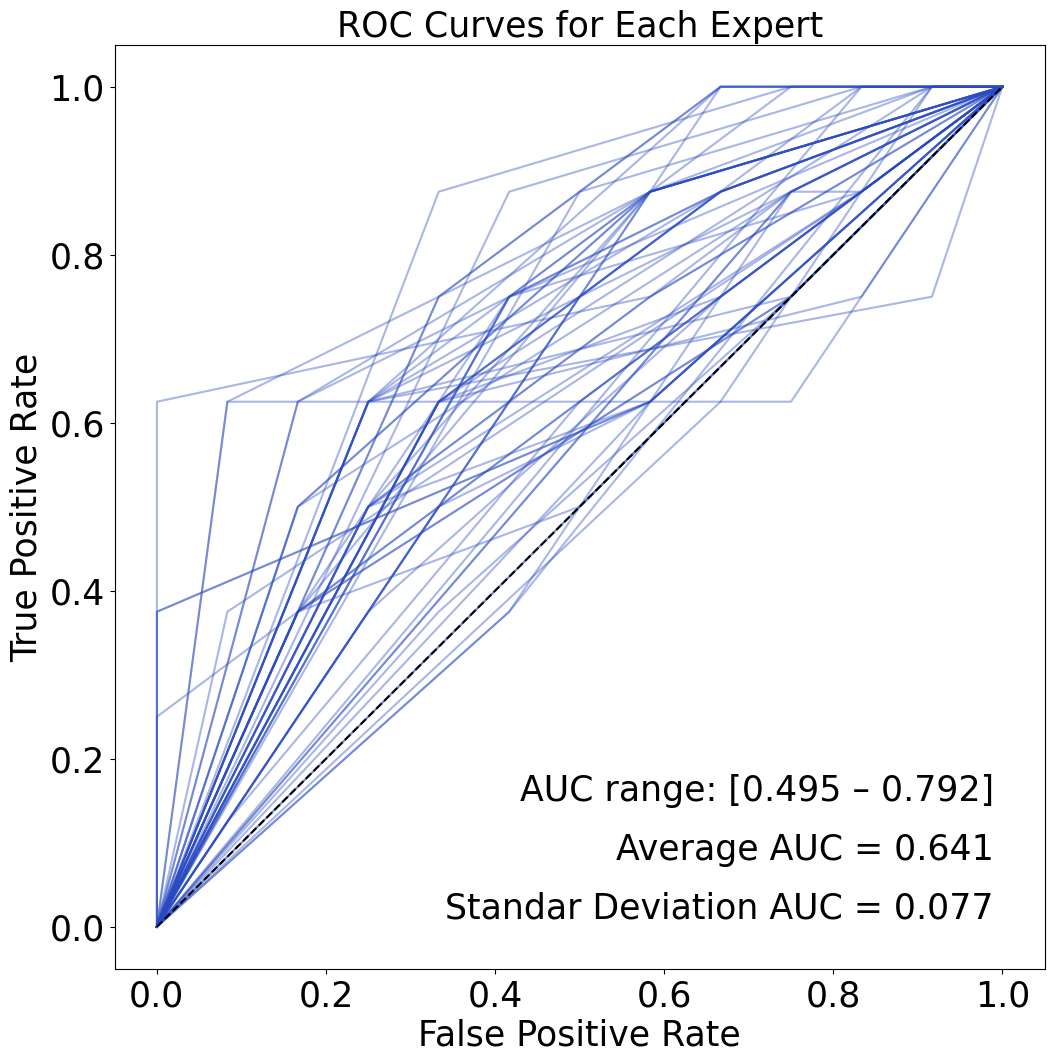

In [77]:
aucs = []
plt.figure(figsize=(12, 12))

for i in range(len(classifications)):

    clasificaciones_medico = classifications.iloc[i]

    fpr, tpr, _ = roc_curve(ground_truth, clasificaciones_medico)
    roc_auc = auc(fpr, tpr)

    aucs.append(roc_auc)

    plt.plot(fpr, tpr, color='#2849C1', alpha=0.4)

# Calculate and display average AUC
auc_promedio = np.mean(aucs)
desviacion_std = np.std(aucs)
max_auc = np.max(aucs)
min_auc = np.min(aucs)
    
plt.plot([0,1], [0,1], linestyle='--', color='black', label="Random")
plt.xlabel("False Positive Rate",  fontsize=25)
plt.ylabel("True Positive Rate",  fontsize=25)
plt.title('ROC Curves for Each Expert',  fontsize=25)

# Aumentar tamaño de los ticks
plt.xticks(fontsize=25)
plt.yticks(fontsize=25)

# Text inside the figure, bottom right
plt.text(0.99, 0.15, f"AUC range: [{min_auc:.3f} – {max_auc:.3f}]",
          fontweight='normal', fontsize=25, ha='right',bbox=dict(facecolor='white', alpha=0.6, edgecolor='none')
         )
plt.text(0.99, 0.08, f"Average AUC = {auc_promedio:.3f}",
          fontweight='normal', fontsize=25, ha='right',bbox=dict(facecolor='white', alpha=0.6, edgecolor='none')
         )
plt.text(0.99, 0.01, f"Standar Deviation AUC = {desviacion_std:.3f}",
          fontweight='normal', fontsize=25, ha='right',bbox=dict(facecolor='white', alpha=0.6, edgecolor='none')
         )

plt.savefig('roc_each_expert.pdf', format="pdf", bbox_inches="tight")
plt.show()


### BORRAR (Gráficas del análisis de los médicos)

In [52]:
df

,Submission Date,Submission IP,Last Update Date,Indique la categoría a la que pertenece:,Escriba los años de experiencia trabajando como científico/a - investigador/a:,Escriba el año de residencia en el que se encuentra:,"En ese caso, indique su tipo de vinculación con el hospital:",(Opcional) Seleccione el hospital de procedencia:,Escriba en el siguiente recuadro su hospital de procedencia:,01/10. ¿Cómo clasifica este RCTG?,...,31/40. ¿Cómo clasifica este RCTG?,32/40. ¿Cómo clasifica este RCTG?,33/40. ¿Cómo clasifica este RCTG?,34/40. ¿Cómo clasifica este RCTG?,35/40. ¿Cómo clasifica este RCTG?,36/40. ¿Cómo clasifica este RCTG?,37/40. ¿Cómo clasifica este RCTG?,38/40. ¿Cómo clasifica este RCTG?,39/40. ¿Cómo clasifica este RCTG?,40/40. ¿Cómo clasifica este RCTG?
0,"Feb 8, 2023",82.158.2.249,NaN,Matrona,2.0,NaN,Adjunto/a,Otro,Hospital Universitario Miguel Servet,Normal,...,Normal,Sospechosa,Patológica,Normal,Sospechosa,Sospechosa,Patológica,Normal,Patológica,Normal
1,"Feb 3, 2023",31.4.136.228,NaN,Matrona,8.0,NaN,Adjunto/a,NaN,NaN,Normal,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,"Feb 1, 2023",139.47.64.113,NaN,Matrona,1.0,NaN,Adjunto/a,Hospital Universitario de Getafe,NaN,Normal,...,Sospechosa,Sospechosa,Normal,Sospechosa,Normal,Normal,Normal,Normal,Patológica,Sospechosa
3,"Feb 1, 2023",79.146.115.154,NaN,Matrona,14.0,NaN,Adjunto/a,Hospital Universitario de Getafe,NaN,Normal,...,Patológica,Patológica,Patológica,Sospechosa,Sospechosa,Patológica,Patológica,Sospechosa,Patológica,Normal
4,"Feb 1, 2023",66.81.172.46,NaN,Matrona,7.0,NaN,Adjunto/a,Hospital Universitario Infanta Cristina,NaN,Normal,...,Patológica,Patológica,Patológica,Sospechosa,Patológica,Patológica,Patológica,Sospechosa,Patológica,Sospechosa
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
57,"May 21, 2022",86.127.243.143,NaN,Matrona,NaN,NaN,Adjunto/a,Hospital Universitario Severo Ochoa,NaN,Normal,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
58,"May 21, 2022",24.148.53.163,NaN,Matrona,NaN,NaN,Adjunto/a,Otro,Extranjero,Normal,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
59,"May 21, 2022",88.12.168.227,NaN,Ginecólogo/a,NaN,NaN,Adjunto/a,NaN,NaN,Normal,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
60,"May 21, 2022",139.47.72.232,NaN,Ginecólogo/a,NaN,NaN,Adjunto/a,Hospital Universitario 12 de Octubre,NaN,Normal,...,Normal,Normal,Patológica,Sospechosa,Sospechosa,Sospechosa,Sospechosa,Normal,Patológica,Normal


In [53]:
data

In [54]:
df.columns

Index(['Submission Date', 'Submission IP', 'Last Update Date',
       'Indique la categoría a la que pertenece:',
       'Escriba los años de experiencia trabajando como científico/a - investigador/a:',
       'Escriba el año de residencia en el que se encuentra:',
       'En ese caso, indique su tipo de vinculación con el hospital:',
       '(Opcional) Seleccione el hospital de procedencia:',
       'Escriba en el siguiente recuadro su hospital de procedencia:',
       '01/10. ¿Cómo clasifica este RCTG?',
       '02/10. ¿Cómo clasifica este RCTG?',
       '03/10. ¿Cómo clasifica este RCTG?',
       '04/10. ¿Cómo clasifica este RCTG?',
       '05/10. ¿Cómo clasifica este RCTG?',
       '06/10. ¿Cómo clasifica este RCTG?',
       '07/10. ¿Cómo clasifica este RCTG?',
       '08/10. ¿Cómo clasifica este RCTG?',
       '09/10. ¿Cómo clasifica este RCTG?',
       '10/10. ¿Cómo clasifica este RCTG?',
       '11/20. ¿Cómo clasifica este RCTG?',
       '12/20. ¿Cómo clasifica este RCTG?',
    

In [55]:
conteo_cargo

NameError: name 'conteo_cargo' is not defined

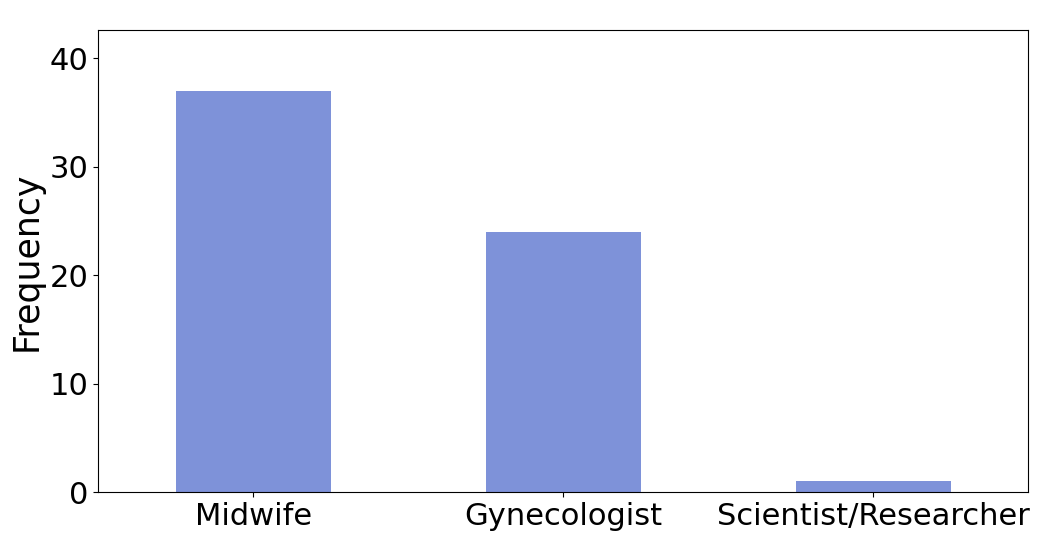

In [56]:
cargo = df['Indique la categoría a la que pertenece:']

cargo = cargo.replace({
    'Matrona': 'Midwife',
    'Ginecólogo/a': 'Gynecologist',
    'Científico/a - Investigador/a': 'Scientist/Researcher',
})

cargo

# Contar la frecuencia de cada categoría
conteo_cargo = cargo.value_counts()

# Crear el gráfico de barras
plt.figure(figsize=(12, 6))
conteo_cargo.plot(kind='bar', color='#2849C1', alpha=0.6)

plt.title(' ')

plt.tick_params(axis="both", labelsize=22)

plt.ylabel('Frequency', fontsize=25)
plt.xticks(rotation=0) 
plt.xlabel('')

# Subir un poco las barras añadiendo margen superior
plt.ylim(0, conteo_cargo.max()*1.15)  # 15% más alto que la barra más alta

# Guardar la figura
plt.savefig("cargo_frecuency.pdf", format="pdf",  bbox_inches='tight')


plt.show()

In [57]:
hospital = df['Escriba en el siguiente recuadro su hospital de procedencia:'].fillna(df['(Opcional) Seleccione el hospital de procedencia:'])
valores_a_reemplazar = ['University','Extranjero',]
hospital = hospital.replace(valores_a_reemplazar, np.nan)

hospital = hospital.replace({
    'Centre hospitalier de Bienne': 'Hospital Biel',
    'Guadalajara': 'Hospital Universitario de Guadalajara',
    'HCU Lozano Blesa': 'Hospital Clínico Universitario Lozano Blesa',
    'Hospital Universitario Nuestra Señora de la Candelaria. Tenerife.': 'Hospital Universitario Nuestra Señora de Candelaria',
    'Hospital de Poniente': 'Hospital Universitario Poniente',
    'Jessop wing, Sheffield, uk.': 'Royal Hallamshire hospital',
    'Peset de Valencia': 'Hospital Universitario Doctor Peset',
    'Royal infirmary of Edinburgh': 'Royal Infirmary of Edinburgh'
})

hospital = hospital.replace({
    'Bedford Hospital': 'Bedford Hospital',
    'Hospital Biel': 'Biel Hospital',
    'Hospital Clínico Universitario Lozano Blesa': 'Lozano Blesa University Clinical Hospital',
    'Hospital General Universitario Gregorio Marañón': 'Gregorio Marañón General University Hospital',
    'Hospital Universitario 12 de Octubre': '12 de Octubre University Hospital',
    'Hospital Universitario Clínico San Carlos': 'San Carlos University Clinical Hospital',
    'Hospital Universitario Doctor Peset': 'Doctor Peset University Hospital',
    'Hospital Universitario Infanta Cristina': 'Infanta Cristina University Hospital',
    'Hospital Universitario Infanta Sofia': 'Infanta Sofia University Hospital',
    'Hospital Universitario Miguel Servet': 'Miguel Servet University Hospital',
    'Hospital Universitario Nuestra Señora de Candelaria': 'Nuestra Señora de Candelaria University Hospital',
    'Hospital Universitario Poniente': 'Poniente University Hospital',
    'Hospital Universitario Príncipe de Asturias': 'Príncipe de Asturias University Hospital',
    'Hospital Universitario Puerta de Hierro': 'Puerta de Hierro University Hospital',
    'Hospital Universitario Rey Juan Carlos': 'Rey Juan Carlos University Hospital',
    'Hospital Universitario Severo Ochoa': 'Severo Ochoa University Hospital',
    'Hospital Universitario de Getafe': 'Getafe University Hospital',
    'Hospital Universitario de Guadalajara': 'Guadalajara University Hospital',
    'Hospital Universitario de Móstoles': 'Móstoles University Hospital',
    'Royal Hallamshire hospital': 'Royal Hallamshire Hospital',
    'Royal Infirmary of Edinburgh': 'Royal Infirmary of Edinburgh',
})


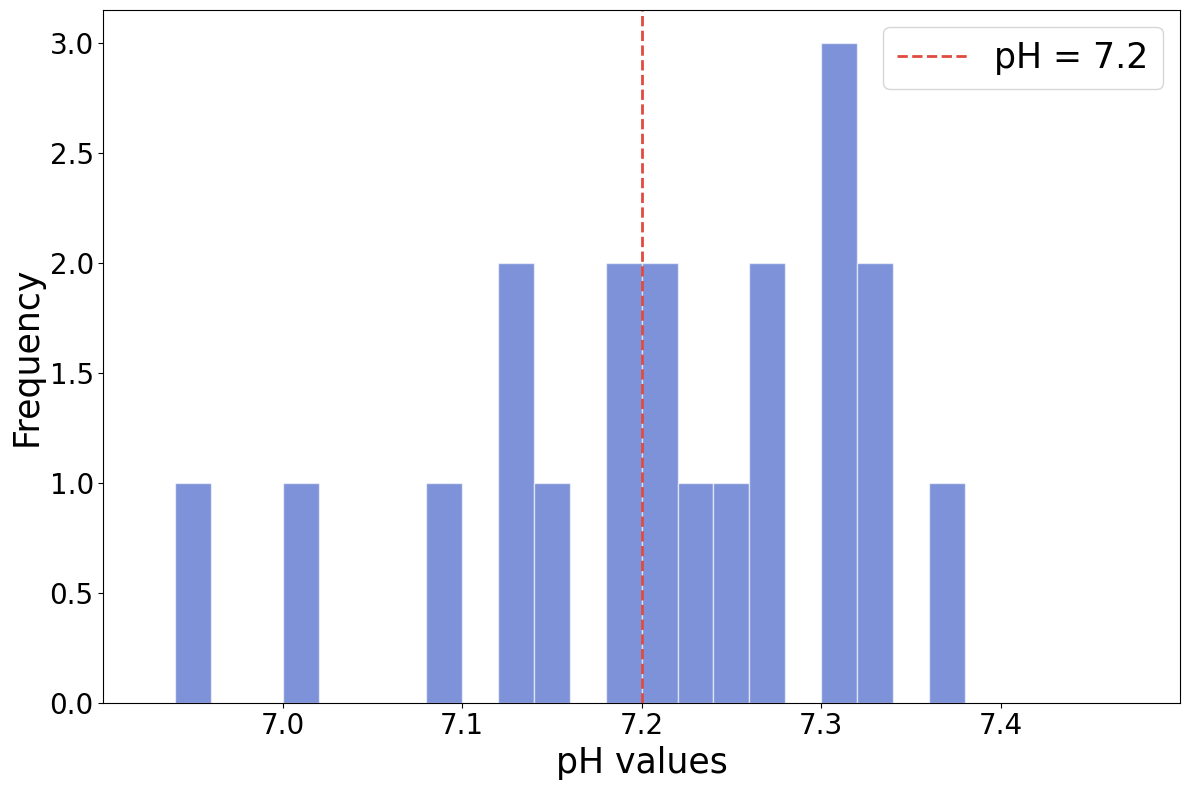

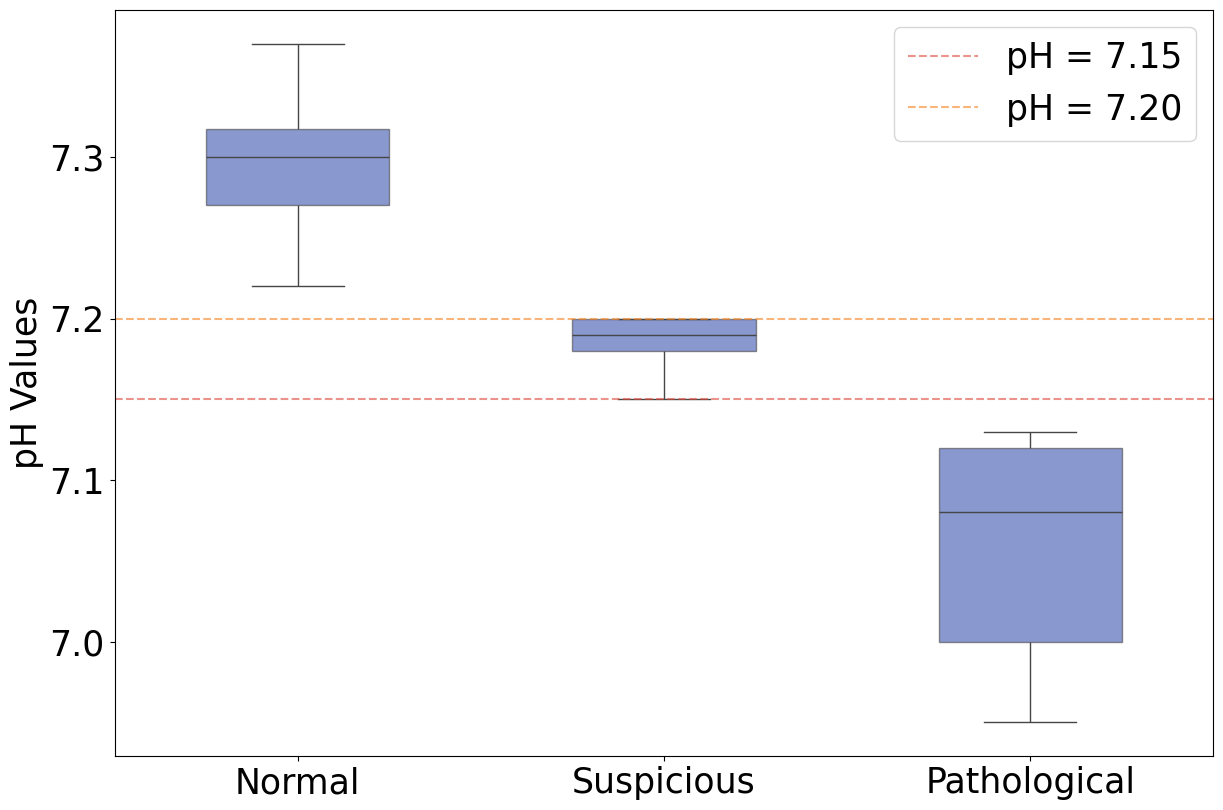

In [58]:
survey_data.ph_histogram()
survey_data.clasificar_ph()

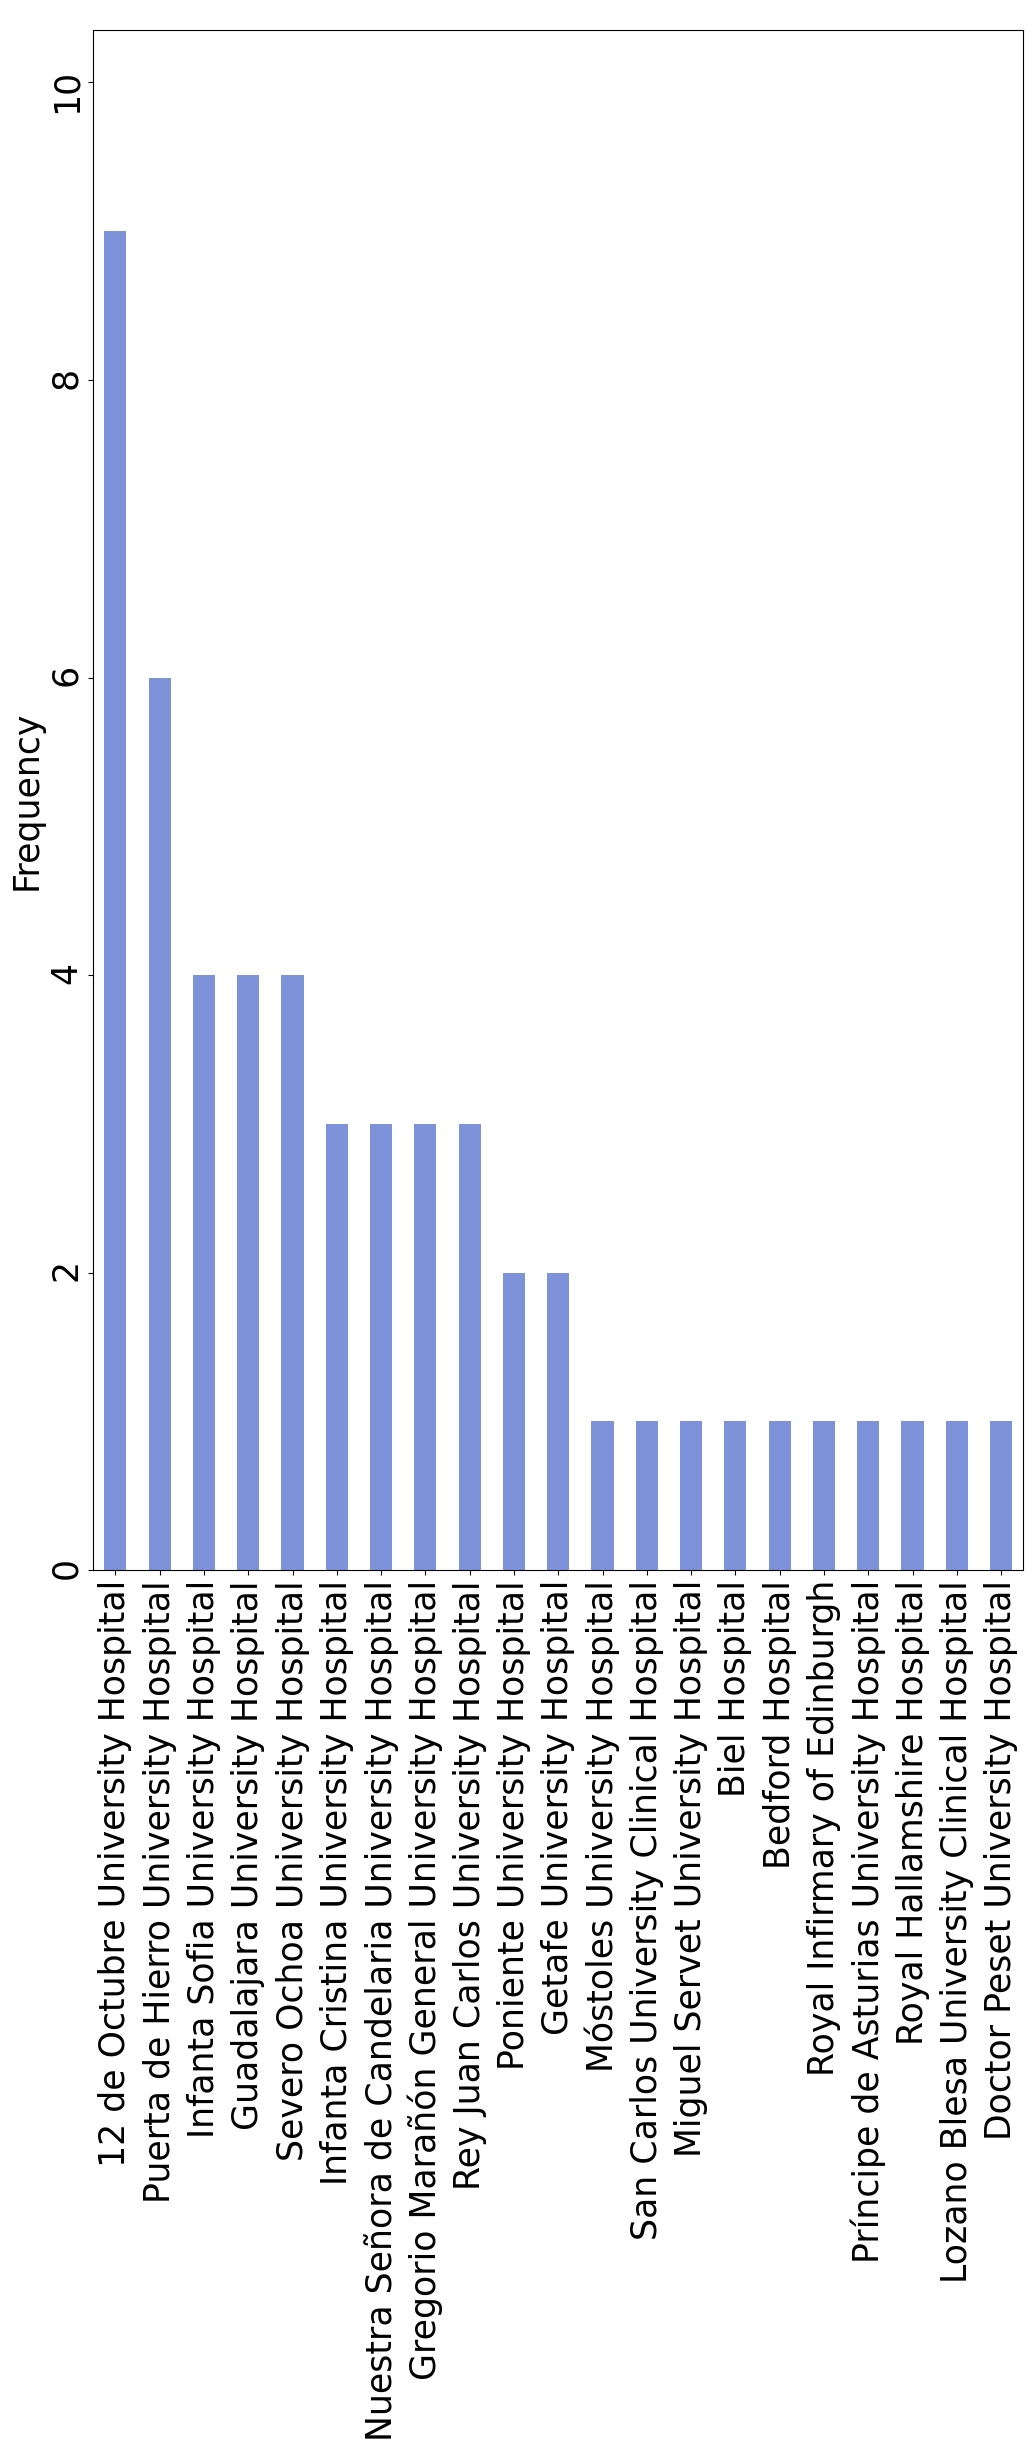

In [63]:
# Contar la frecuencia de cada categoría
conteo = hospital.value_counts()

# Crear el gráfico de barras
plt.figure(figsize=(12,20))
conteo.plot(kind='bar', color='#2849C1', alpha=0.6)

plt.title(' ')

plt.tick_params(axis="both", labelsize=25)

plt.ylabel('Frequency', fontsize=25)
plt.yticks(rotation=90) 
plt.xlabel('')

# Subir un poco las barras añadiendo margen superior
plt.ylim(0, conteo.max()*1.15)  # 15% más alto que la barra más alta

# Guardar la figura
plt.savefig("hospital_frequency.pdf", format="pdf",  bbox_inches='tight')


plt.show()

### Suavizado con FDA y Gráfico de fases

In [217]:
print("Índice | Valor pH")
print("-----------------")
for i, ph in enumerate(data.phs):
    print(f"   {i}   |   {ph}")

Índice | Valor pH
-----------------
   0   |   7.3
   1   |   7.29
   2   |   7.23
   3   |   7.28
   4   |   7.08
   5   |   7.03
   6   |   7.33
   7   |   7.3
   8   |   7.2
   9   |   7.28
   10   |   7.34
   11   |   7.13
   12   |   7.32
   13   |   7.21
   14   |   7.24
   15   |   7.47
   16   |   7.13
   17   |   7.29
   18   |   7.3
   19   |   7.37
   20   |   7.14
   21   |   7.27
   22   |   7.34
   23   |   7.07
   24   |   7.35
   25   |   7.29
   26   |   7.11
   27   |   7.14
   28   |   7.3
   29   |   7.25
   30   |   7.21
   31   |   7.35
   32   |   7.28
   33   |   7.37
   34   |   7.28
   35   |   7.21
   36   |   7.18
   37   |   7.31
   38   |   7.34
   39   |   7.23
   40   |   7.27
   41   |   7.17
   42   |   7.27
   43   |   7.03
   44   |   7.29
   45   |   7.21
   46   |   7.02
   47   |   7.26
   48   |   7.2
   49   |   7.32
   50   |   7.21
   51   |   6.98
   52   |   7.19
   53   |   7.44
   54   |   7.23
   55   |   7.18
   56   |   7.13
   57   |  

Número de puntos críticos de la FHR -> 64
Kinetic Energy (Ec) -> Max: 1.630015e+04, Min: 7.319399e+03
Potential Energy (Ep) -> Max: 1.088032e+01, Min: 3.019233e-08
Total Energy (Em) -> Max: 1.630018e+04, Min: 1.630018e+04
Area de la curva -> 1.623950e+03
Longitud de la curva -> 9.805744e+02


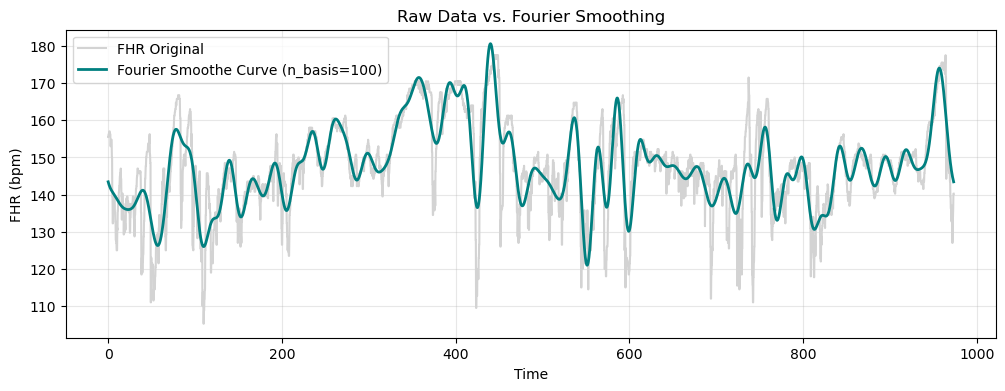

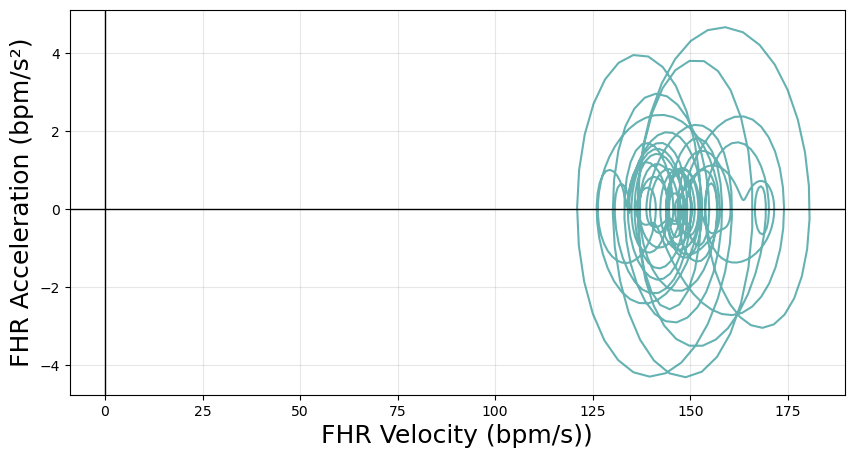

In [91]:
# No hipoxia
data.ctgs[362].smoothe(n_basis = 100, plot_smooth_graph = True, plot_fase_graph = True, get_enery_info = True, get_area_fase = True, get_len_curva = True)

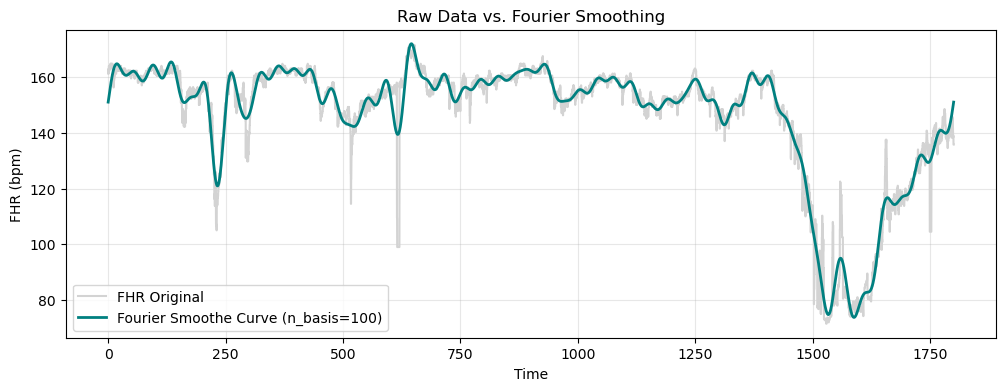

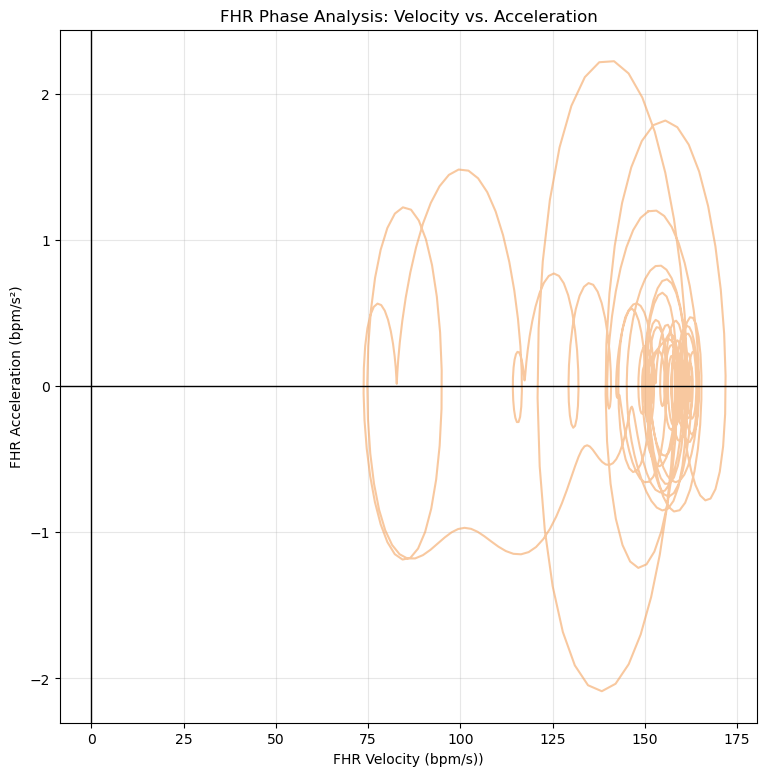

Número de puntos críticos de la FHR -> 70
Kinetic Energy (Ec) -> Max: 1.477875e+04, Min: 2.721562e+03
Potential Energy (Ep) -> Max: 2.468275e+00, Min: 7.175663e-08
Total Energy (Em) -> Max: 1.477876e+04, Min: 1.477876e+04
Area de la curva -> 5.096361e+02
Longitud de la curva -> 6.829700e+02


In [241]:
# 9 (publica) -> gaps
# 222 (publica) -> más n_basis
data.ctgs[368].smoothe(n_basis = 100,  plot_smooth_graph = True, plot_fase_graph = True, get_enery_info = True, get_area_fase = True, get_len_curva = True)

In [223]:
mechanic_energy_hipoxia = []
mechanic_energy_healthy = []

for ctg in data.ctgs: 
    res = ctg.smoothe(n_basis=100, get_mechanic_energy = True)
    if res == -1:
        continue
    else:
        if ctg.ph <7.20:
            mechanic_energy_hipoxia.append(res)
        else: 
            mechanic_energy_healthy.append(res)

FIN ANÁLISIS: El 21.83% del tiempo la señal original toma valor NaN.
FIN ANÁLISIS: El 22.31% del tiempo la señal original toma valor NaN.
FIN ANÁLISIS: El 22.92% del tiempo la señal original toma valor NaN.
FIN ANÁLISIS: El 25.98% del tiempo la señal original toma valor NaN.
FIN ANÁLISIS: El 33.24% del tiempo la señal original toma valor NaN.
FIN ANÁLISIS: El 33.16% del tiempo la señal original toma valor NaN.
FIN ANÁLISIS: El 38.87% del tiempo la señal original toma valor NaN.
FIN ANÁLISIS: El 43.69% del tiempo la señal original toma valor NaN.
FIN ANÁLISIS: El 39.65% del tiempo la señal original toma valor NaN.
FIN ANÁLISIS: El 29.64% del tiempo la señal original toma valor NaN.
FIN ANÁLISIS: El 26.97% del tiempo la señal original toma valor NaN.
FIN ANÁLISIS: El 23.31% del tiempo la señal original toma valor NaN.
FIN ANÁLISIS: El 28.11% del tiempo la señal original toma valor NaN.
FIN ANÁLISIS: El 27.99% del tiempo la señal original toma valor NaN.
FIN ANÁLISIS: El 26.24% del tiempo

FIN ANÁLISIS: El 36.43% del tiempo la señal original toma valor NaN.
FIN ANÁLISIS: El 62.31% del tiempo la señal original toma valor NaN.
FIN ANÁLISIS: El 24.11% del tiempo la señal original toma valor NaN.
FIN ANÁLISIS: El 72.68% del tiempo la señal original toma valor NaN.
FIN ANÁLISIS: El 56.22% del tiempo la señal original toma valor NaN.
FIN ANÁLISIS: El 43.68% del tiempo la señal original toma valor NaN.
FIN ANÁLISIS: El 37.08% del tiempo la señal original toma valor NaN.
FIN ANÁLISIS: El 26.62% del tiempo la señal original toma valor NaN.
FIN ANÁLISIS: El 31.10% del tiempo la señal original toma valor NaN.
FIN ANÁLISIS: El 32.39% del tiempo la señal original toma valor NaN.
FIN ANÁLISIS: El 48.40% del tiempo la señal original toma valor NaN.
FIN ANÁLISIS: El 27.39% del tiempo la señal original toma valor NaN.
FIN ANÁLISIS: El 30.68% del tiempo la señal original toma valor NaN.
FIN ANÁLISIS: El 20.14% del tiempo la señal original toma valor NaN.
FIN ANÁLISIS: El 48.86% del tiempo

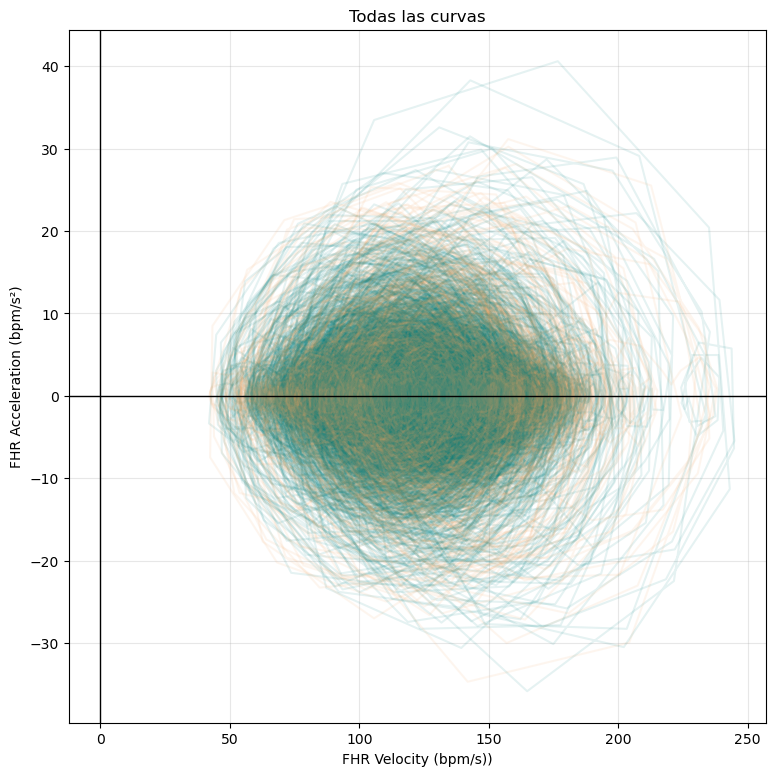

Saltadas: 40.00
Pintadas: 152.00


In [239]:
plt.figure(figsize=(9, 9))
ax = plt.gca()


ctg_saltadas = 0
ctg_pintadas = 0

for ctg in data.ctgs: 
    if ctg.ph<7.1 or ctg.ph>7.30:
        res = ctg.smoothe(n_basis=400, plot_fase_graph = True, create_figure = False)
        if res == -1:
            ctg_saltadas+=1
        else:
            ctg_pintadas+=1

plt.title("Todas las curvas")
plt.xlabel("FHR Velocity (bpm/s))")
plt.ylabel("FHR Acceleration (bpm/s²)")
plt.axhline(0, color="black", lw=1)
plt.axvline(0, color="black", lw=1)
plt.grid(True, alpha=0.3)
plt.show()

print(f"Saltadas: {ctg_saltadas:.2f}")
print(f"Pintadas: {ctg_pintadas:.2f}")

In [224]:
print(f"Total Energy in Hipoxia Case -> Mean: {np.mean(mechanic_energy_hipoxia):e}, Std: {np.std(mechanic_energy_hipoxia, ddof=1):e}")
print(f"Total Energy in Healthy Case -> Mean: {np.mean(mechanic_energy_healthy):e}, Std: {np.std(mechanic_energy_healthy, ddof=1):e}")

Total Energy in Hipoxia Case -> Mean: 1.491335e+04, Std: 2.516086e+03
Total Energy in Healthy Case -> Mean: 1.415600e+04, Std: 2.680996e+03


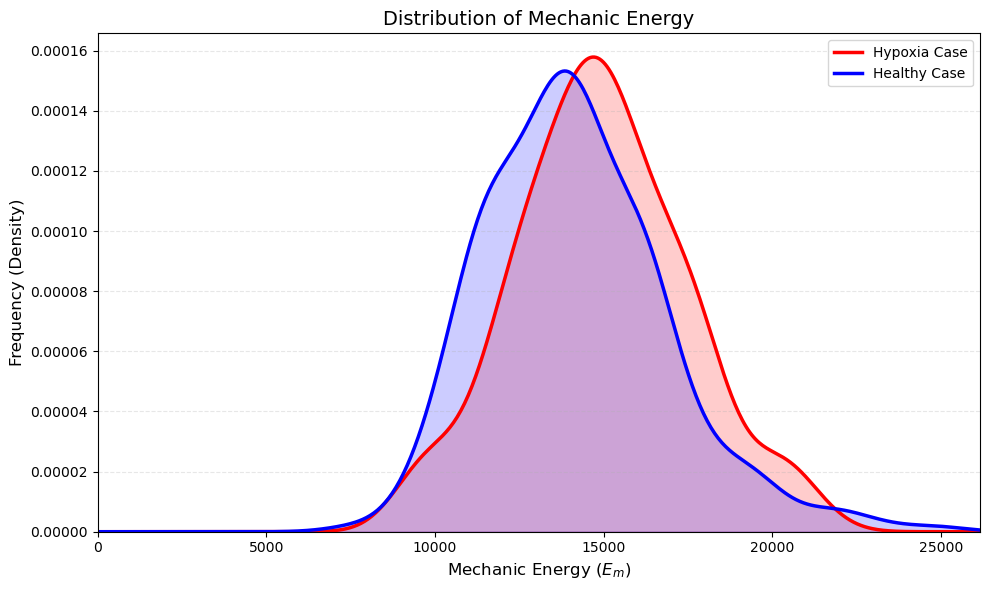

In [225]:
from scipy.stats import gaussian_kde

# Configurar el rango del eje X para la Energía (desde 0 hasta un poco más del máximo)
all_energy = mechanic_energy_hipoxia + mechanic_energy_healthy
x_range = np.linspace(0, np.max(all_energy) * 1.1, 500)

# Calcular las funciones de densidad
kde_hipoxia = gaussian_kde(mechanic_energy_hipoxia)
y_hipoxia = kde_hipoxia(x_range)

kde_healthy = gaussian_kde(mechanic_energy_healthy)
y_healthy = kde_healthy(x_range)

# Crear el gráfico
plt.figure(figsize=(10, 6))

# Dibujar curvas
plt.plot(x_range, y_hipoxia, color='red', lw=2.5, label='Hypoxia Case')
plt.fill_between(x_range, y_hipoxia, color='red', alpha=0.2) # Relleno suave

plt.plot(x_range, y_healthy, color='blue', lw=2.5, label='Healthy Case')
plt.fill_between(x_range, y_healthy, color='blue', alpha=0.2) # Relleno suave

# Configuración de ejes
plt.title('Distribution of Mechanic Energy', fontsize=14)
plt.xlabel('Mechanic Energy ($E_m$)', fontsize=12)
plt.ylabel('Frequency (Density)', fontsize=12)
plt.legend()
plt.grid(axis='y', alpha=0.3, linestyle='--')

# Ajustar límites para que se vea limpio
plt.xlim(0, np.max(all_energy) * 1.05)
plt.ylim(0, None)

plt.tight_layout()
plt.show()

Porcentaje de NaNs en la señal original: 0.61%
Porcentaje de NaNs en la señal original: 49.43%
Porcentaje de NaNs en la señal original: 1.05%
Porcentaje de NaNs en la señal original: 4.06%
Porcentaje de NaNs en la señal original: 42.77%
Porcentaje de NaNs en la señal original: 1.90%
Porcentaje de NaNs en la señal original: 0.49%
Porcentaje de NaNs en la señal original: 1.15%
Porcentaje de NaNs en la señal original: 41.99%
Porcentaje de NaNs en la señal original: 8.62%
Porcentaje de NaNs en la señal original: 9.93%
Porcentaje de NaNs en la señal original: 1.33%
Porcentaje de NaNs en la señal original: 0.53%
Porcentaje de NaNs en la señal original: 1.92%
Porcentaje de NaNs en la señal original: 63.05%
Porcentaje de NaNs en la señal original: 2.69%
Porcentaje de NaNs en la señal original: 31.06%
Porcentaje de NaNs en la señal original: 27.63%
Porcentaje de NaNs en la señal original: 1.78%
Porcentaje de NaNs en la señal original: 4.46%
Porcentaje de NaNs en la señal original: 2.17%
Porcent

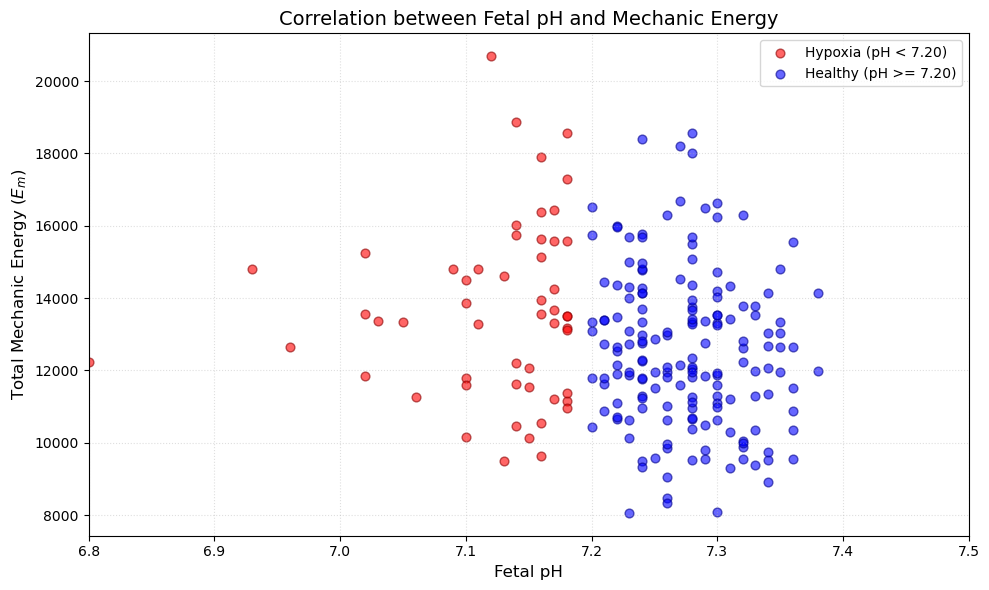

In [187]:
ph_hipoxia = []
energy_hipoxia = []

ph_healthy = []
energy_healthy = []


for ctg in data.ctgs: 
    energy = ctg.smoothe(get_mechanic_energy=True)
    
    if ctg.ph < 7.20:
        ph_hipoxia.append(ctg.ph)
        energy_hipoxia.append(energy)
    else: 
        ph_healthy.append(ctg.ph)
        energy_healthy.append(energy)


plt.figure(figsize=(10, 6))

plt.scatter(ph_hipoxia, energy_hipoxia, color='red', label='Hypoxia (pH < 7.20)', 
            alpha=0.6, edgecolors='darkred', s=40)
plt.scatter(ph_healthy, energy_healthy, color='blue', label='Healthy (pH >= 7.20)', 
            alpha=0.6, edgecolors='darkblue', s=40)


plt.xlim(6.8, 7.5) # Cortamos el eje X en 6.8
plt.title('Correlation between Fetal pH and Mechanic Energy', fontsize=14)
plt.xlabel('Fetal pH', fontsize=12)
plt.ylabel('Total Mechanic Energy ($E_m$)', fontsize=12)

plt.legend()
plt.grid(True, linestyle=':', alpha=0.4)

plt.tight_layout()
plt.show()

ph:  7.39


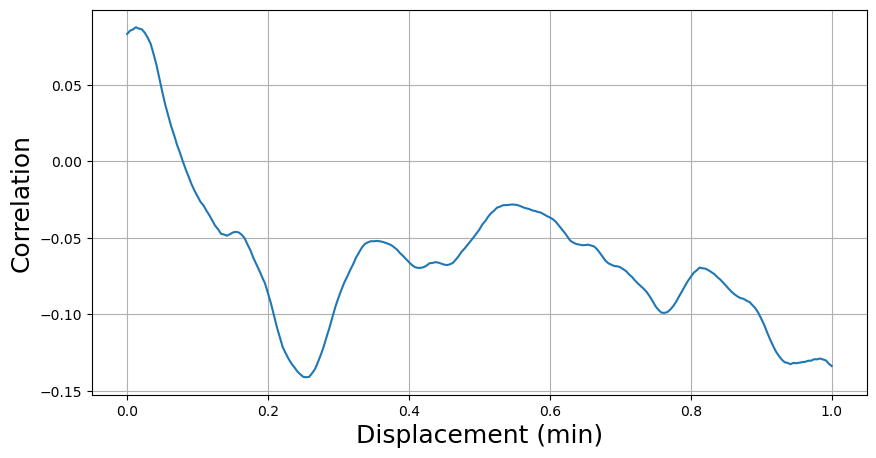

La correlación mínima es: -0.14
Ocurre con un desplazamiento de: 61.00 puntos -> 0.25 minutos


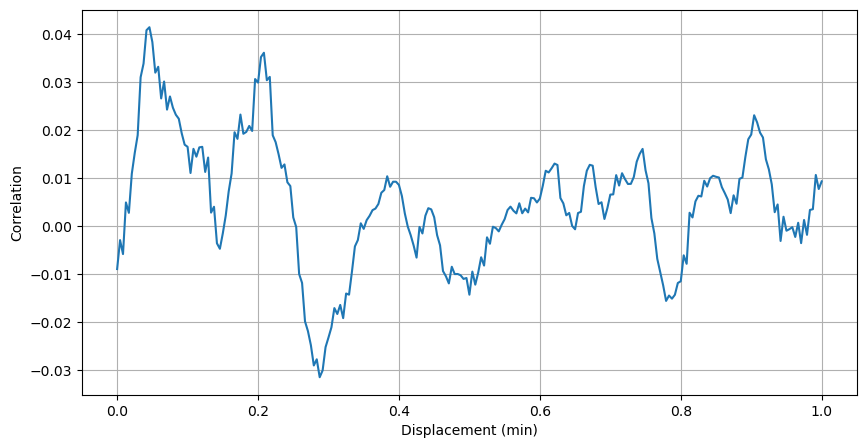

La correlación mínima es: -0.03
Ocurre con un desplazamiento de: 69.00 puntos -> 0.29 minutos


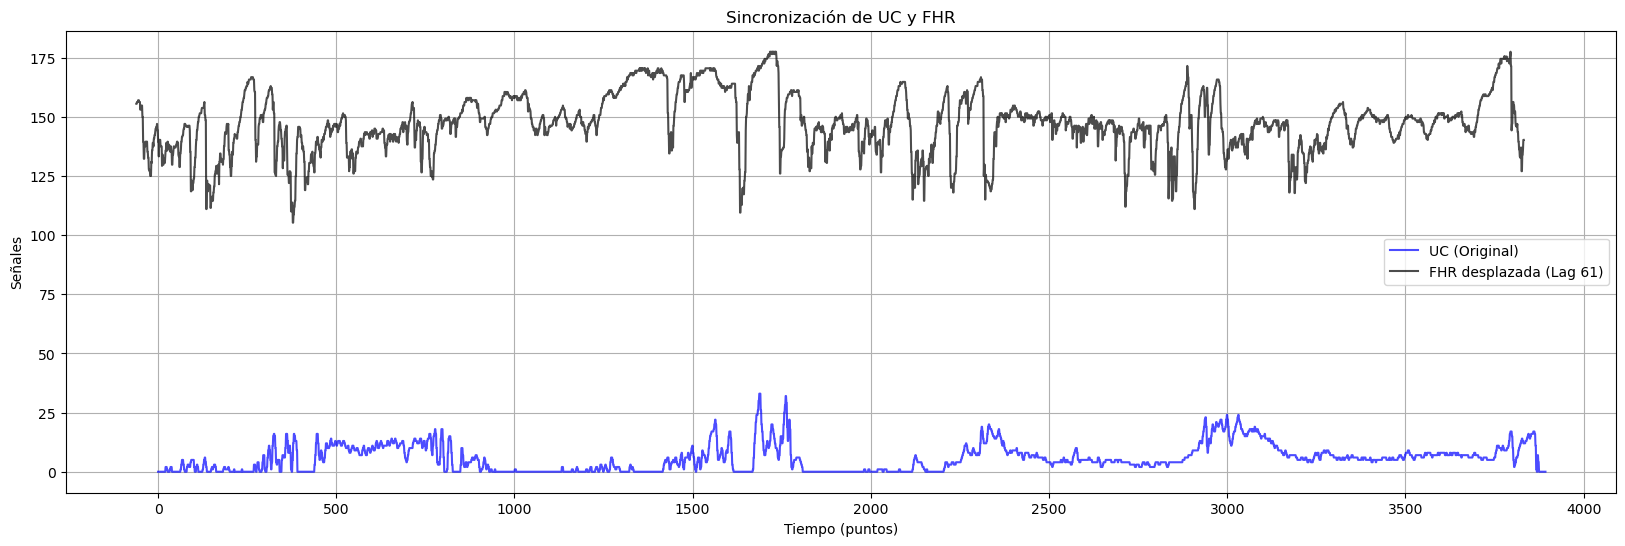

In [93]:
print("ph: ",data.ctgs[362].ph)
res = data.ctgs[362].get_corr_fun(max_desplazamiento=1)

ph:  7.39


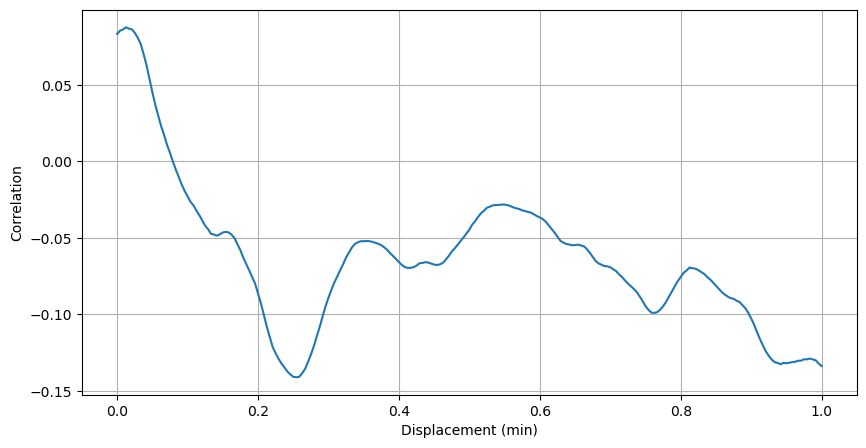

La correlación mínima es: -0.14
Ocurre con un desplazamiento de: 61.00 puntos -> 0.25 minutos


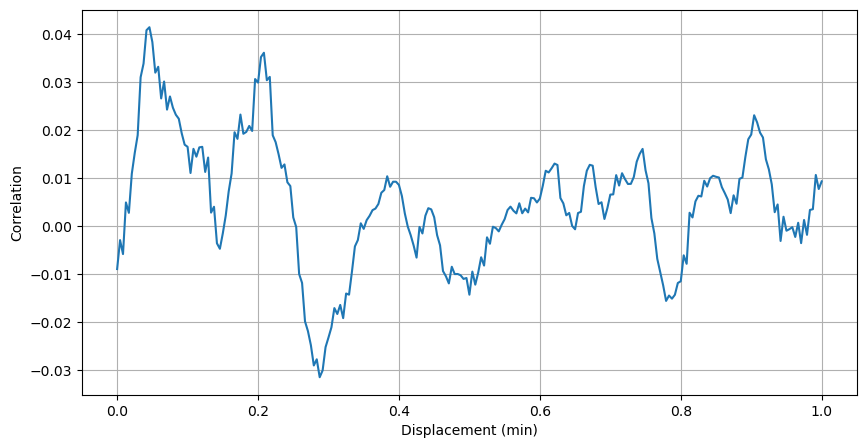

La correlación mínima es: -0.03
Ocurre con un desplazamiento de: 69.00 puntos -> 0.29 minutos


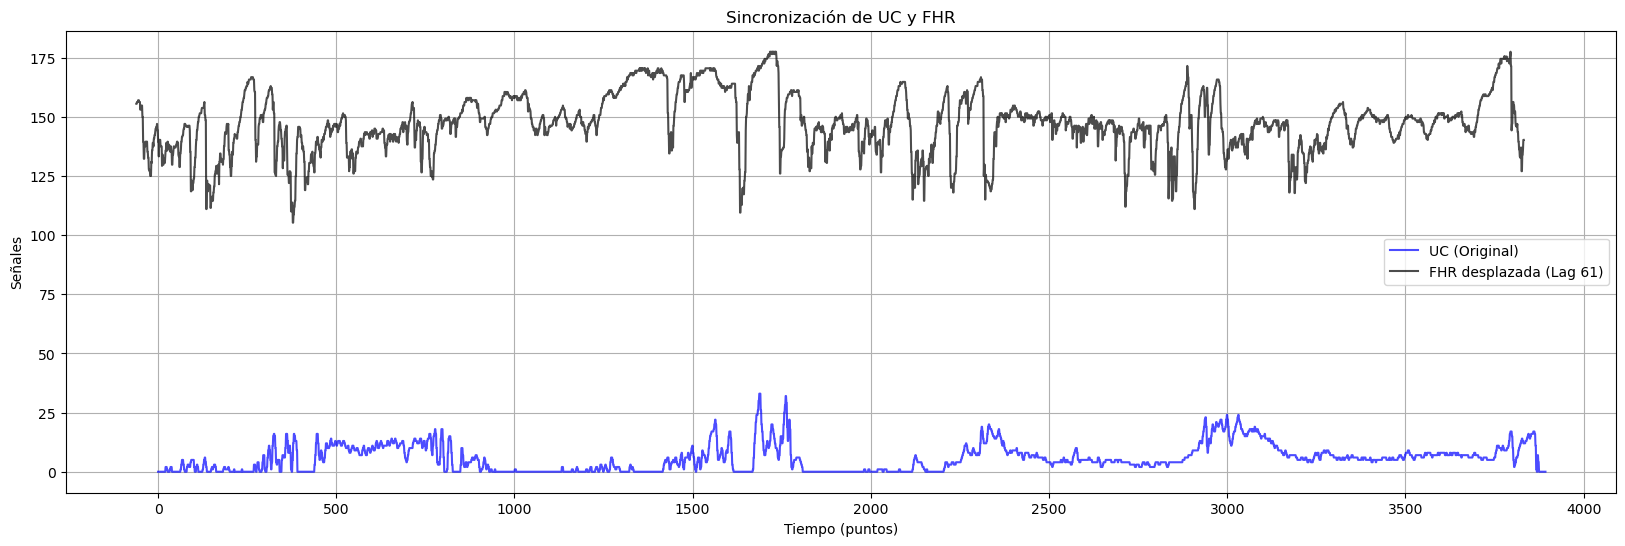

In [41]:
print("ph: ",data.ctgs[362].ph)
res = data.ctgs[362].get_corr_fun(max_desplazamiento=1)

In [56]:
_ = data.get_ctg_by_id(1104).get_corr_fun()

Señal plana o inválida.


1 : Señal  1155  ( ph =  7.34 ) plana o inválida.
2 : Señal  1451  ( ph =  7.05 ) plana o inválida.
3 : Señal  2005  ( ph =  7.25 ) plana o inválida.
4 : Señal  2039  ( ph =  7.32 ) plana o inválida.
5 : Señal  1296  ( ph =  7.2 ) plana o inválida.
6 : Señal  2003  ( ph =  6.96 ) plana o inválida.
7 : Señal  1482  ( ph =  7.22 ) plana o inválida.
8 : Señal  1079  ( ph =  7.17 ) plana o inválida.
9 : Señal  2026  ( ph =  7.23 ) plana o inválida.
10 : Señal  1258  ( ph =  7.17 ) plana o inválida.
11 : Señal  1104  ( ph =  6.92 ) plana o inválida.
12 : Señal  1188  ( ph =  7.19 ) plana o inválida.
Señales saltadas:  12  /  552


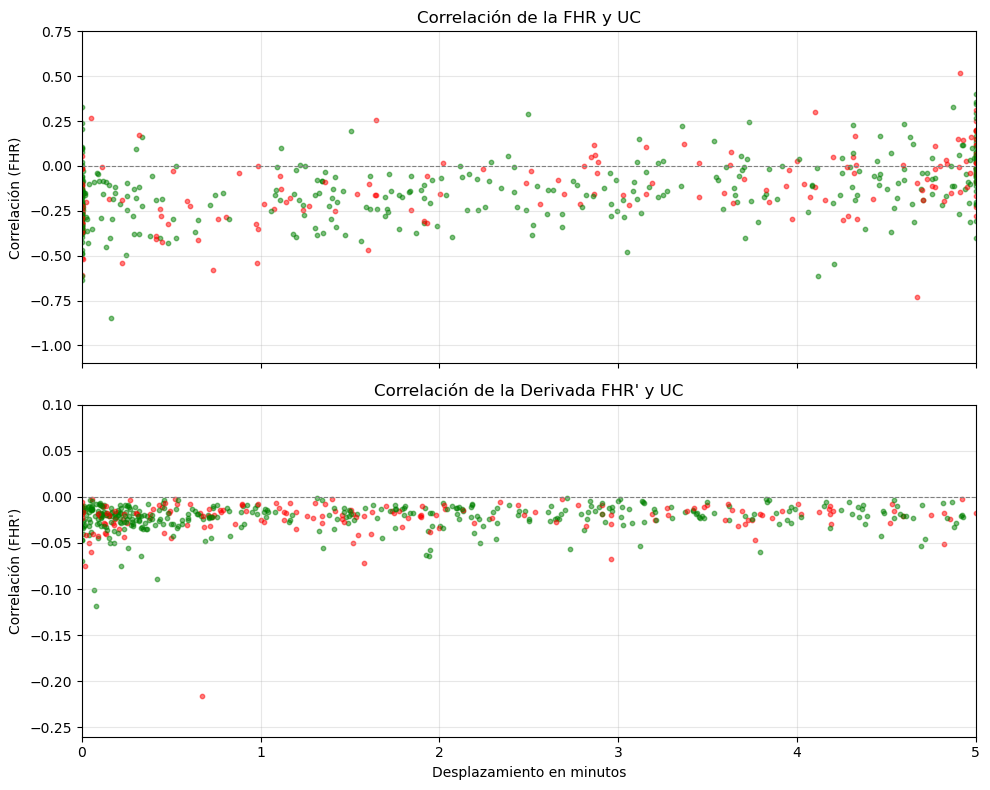

In [149]:
data.get_corr()

In [126]:
ctg_example = data.ctgs[6]

In [ ]:
validos_uc = ~np.isnan(ctg_example.fhr)
ctg_example.fhr[validos_uc]

450.75    NaN
451.00    NaN
451.25    NaN
451.50    NaN
451.75    NaN
           ..
1699.50   NaN
1699.75   NaN
1700.00   NaN
1700.25   NaN
1700.50   NaN
Length: 427, dtype: float64

In [134]:
a = [10,3,5,8,2]
np.diff(a)


array([-7,  2,  3, -6])

### InceptionTime

In [ ]:
from tsai.models.InceptionTime import InceptionTime
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split

In [47]:
import numpy as np
import torch
import torch.nn as nn
from sklearn.model_selection import train_test_split

# ==========================================
# 1. PREPARACIÓN DE DATOS CON DOWNSAMPLING (¡8x más rápido!)
# ==========================================
X_tf, y_tf = data.get_tf_ctgs()
X_np = np.asarray(X_tf, dtype=np.float32)
y_np = np.asarray(y_tf, dtype=np.int64)

X_np = np.nan_to_num(X_np, nan=0.0)

# # ¡PASO CLAVE DE VELOCIDAD! Downsampling: tomamos un punto cada 8 pasos temporales.
# # Tus 7200 puntos pasan a ser 900 puntos. La carga matemática se desploma.
# X_np = X_np[:, :, ::8] 

# Re-calculamos la longitud de la secuencia para la red
NUEVA_LONGITUD = X_np.shape[2] # Debería ser 900

X_train, X_val, y_train, y_val = train_test_split(
    X_np, y_np, test_size=0.20, random_state=42, stratify=y_np
)

X_train_t = torch.from_numpy(X_train)
y_train_t = torch.from_numpy(y_train)
X_val_t = torch.from_numpy(X_val)
y_val_t = torch.from_numpy(y_val)

print(f"Datos ultra-optimizados. Nueva forma: {X_train_t.shape}")

# ==========================================
# 2. ARQUITECTURA ULTRA-LIGERA (Sin LayerNorm)
# ==========================================
class InceptionBlock1D(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(InceptionBlock1D, self).__init__()
        # Convoluciones tradicionales en paralelo
        self.conv_short = nn.Conv1d(in_channels, out_channels, kernel_size=3, padding=1)
        self.conv_medium = nn.Conv1d(in_channels, out_channels, kernel_size=7, padding=3)
        self.conv_long = nn.Conv1d(in_channels, out_channels, kernel_size=11, padding=5)
        
        # Eliminamos LayerNorm para que la CPU no sufra.
        self.relu = nn.ReLU()

    def forward(self, x):
        res = torch.cat([self.conv_short(x), self.conv_medium(x), self.conv_long(x)], dim=1)
        return self.relu(res)

class CTGInceptionNet(nn.Module):
    def __init__(self, num_classes=2):
        super(CTGInceptionNet, self).__init__()
        self.inception1 = InceptionBlock1D(in_channels=2, out_channels=8) # Bajamos filtros de 16 a 8
        self.inception2 = InceptionBlock1D(in_channels=24, out_channels=16) # Bajamos filtros de 32 a 16
        self.pool = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Linear(48, num_classes)

    def forward(self, x):
        x = self.inception1(x)
        x = self.inception2(x)
        x = self.pool(x).squeeze(-1)
        return self.fc(x)

device = torch.device("cpu")
model = CTGInceptionNet(num_classes=2).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# ==========================================
# 3. BUCLE DE ENTRENAMIENTO VELOZ
# ==========================================
epochs = 20
batch_size = 32
num_muestras_train = X_train_t.shape[0]

print(f"Iniciando entrenamiento veloz en: {device}\n" + "-"*30)

for epoch in range(epochs):
    model.train()
    train_loss, correct_train, total_train = 0.0, 0, 0
    
    indices = torch.randperm(num_muestras_train)
    X_train_shuffled = X_train_t[indices]
    y_train_shuffled = y_train_t[indices]
    
    for i in range(0, num_muestras_train, batch_size):
        inputs = X_train_shuffled[i : i + batch_size]
        labels = y_train_shuffled[i : i + batch_size]
        
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        
        # El clipping se queda para evitar los NaNs de forma barata sin usar memoria
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        
        optimizer.step()
        
        train_loss += loss.item() * inputs.size(0)
        _, predicted = outputs.max(1)
        total_train += labels.size(0)
        correct_train += predicted.eq(labels).sum().item()
        
    epoch_train_loss = train_loss / total_train
    epoch_train_acc = 100.0 * correct_train / total_train
    
    # --- FASE DE VALIDACIÓN ---
    model.eval()
    with torch.no_grad():
        outputs = model(X_val_t)
        loss = criterion(outputs, y_val_t)
        val_loss = loss.item() * X_val_t.size(0)
        _, predicted = outputs.max(1)
        correct_val = predicted.eq(y_val_t).sum().item()
            
    epoch_val_loss = val_loss / y_val_t.size(0)
    epoch_val_acc = 100.0 * correct_val / y_val_t.size(0)
    
    print(f"Época [{epoch+1:02d}/{epochs}] -> "
          f"Train Loss: {epoch_train_loss:.4f} | Train Acc: {epoch_train_acc:.2f}% || "
          f"Val Loss: {epoch_val_loss:.4f} | Val Acc: {epoch_val_acc:.2f}%")

print("-"*30 + "\n¡Entrenamiento completado!")

Datos ultra-optimizados. Nueva forma: torch.Size([441, 2, 900])
Iniciando entrenamiento veloz en: cpu
------------------------------
Época [01/20] -> Train Loss: 1.1988 | Train Acc: 51.70% || Val Loss: 0.6712 | Val Acc: 55.86%
Época [02/20] -> Train Loss: 0.9379 | Train Acc: 54.88% || Val Loss: 1.1564 | Val Acc: 65.77%
Época [03/20] -> Train Loss: 0.9040 | Train Acc: 52.83% || Val Loss: 0.6236 | Val Acc: 67.57%
Época [04/20] -> Train Loss: 0.7646 | Train Acc: 58.96% || Val Loss: 0.8433 | Val Acc: 64.86%
Época [05/20] -> Train Loss: 0.6763 | Train Acc: 59.86% || Val Loss: 0.6955 | Val Acc: 66.67%
Época [06/20] -> Train Loss: 1.1295 | Train Acc: 53.29% || Val Loss: 0.6461 | Val Acc: 67.57%
Época [07/20] -> Train Loss: 0.6819 | Train Acc: 60.54% || Val Loss: 0.6470 | Val Acc: 68.47%
Época [08/20] -> Train Loss: 0.7100 | Train Acc: 61.22% || Val Loss: 1.2173 | Val Acc: 34.23%
Época [09/20] -> Train Loss: 0.9373 | Train Acc: 53.29% || Val Loss: 0.6232 | Val Acc: 66.67%
Época [10/20] -> Trai

KeyboardInterrupt: 

In [45]:
# Añadimos el '_' en el medio para recibir el tercer valor
valores, _, conteos = tf.unique_with_counts(y_tf)

for v, c in zip(valores.numpy(), conteos.numpy()):
    print(f"Clase {v}: {c} muestras")

Clase 0: 358 muestras
Clase 1: 194 muestras


In [48]:
X_tf, y_tf = data.get_tf_ctgs()

In [9]:
from chronos import ChronosPipeline

/opt/miniconda3/envs/torch_cpu/lib/python3.10/site-packages/torchvision/io/image.py:14: UserWarning: Failed to load image Python extension: 'dlopen(/opt/miniconda3/envs/torch_cpu/lib/python3.10/site-packages/torchvision/image.so, 0x0006): Library not loaded: @rpath/libjpeg.9.dylib
  Referenced from: <0B7EB158-53DC-3403-8A49-22178CAB4612> /opt/miniconda3/envs/torch_cpu/lib/python3.10/site-packages/torchvision/image.so
  Reason: tried: '/opt/miniconda3/envs/torch_cpu/lib/python3.10/site-packages/torchvision/../../../libjpeg.9.dylib' (no such file), '/opt/miniconda3/envs/torch_cpu/lib/python3.10/site-packages/torchvision/../../../libjpeg.9.dylib' (no such file), '/opt/miniconda3/envs/torch_cpu/lib/python3.10/lib-dynload/../../libjpeg.9.dylib' (no such file), '/opt/miniconda3/envs/torch_cpu/bin/../lib/libjpeg.9.dylib' (no such file)'If you don't plan on using image functionality from `torchvision.io`, you can ignore this warning. Otherwise, there might be something wrong with your environm

In [10]:
pipeline = ChronosPipeline.from_pretrained(
  "amazon/chronos-t5-small",
  device_map="cpu",
  dtype=torch.float32,
)

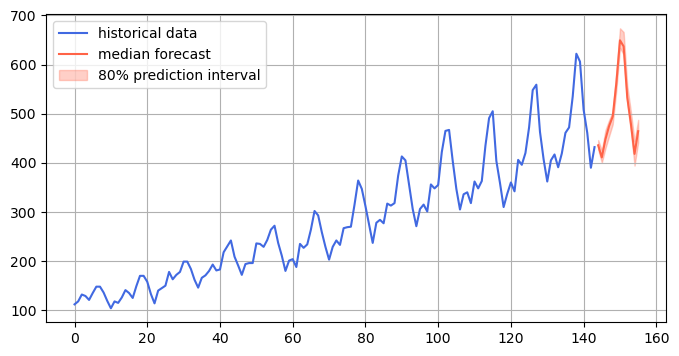

In [54]:
df = pd.read_csv("https://raw.githubusercontent.com/AileenNielsen/TimeSeriesAnalysisWithPython/master/data/AirPassengers.csv")


context = torch.tensor(df["#Passengers"])
prediction_length = 12
forecast = pipeline.predict(context, prediction_length)  # shape [num_series, num_samples, prediction_length]

forecast_index = range(len(df), len(df) + prediction_length)
low, median, high = np.quantile(forecast[0].numpy(), [0.1, 0.5, 0.9], axis=0)

plt.figure(figsize=(8, 4))
plt.plot(df["#Passengers"], color="royalblue", label="historical data")
plt.plot(forecast_index, median, color="tomato", label="median forecast")
plt.fill_between(forecast_index, low, high, color="tomato", alpha=0.3, label="80% prediction interval")
plt.legend()
plt.grid()
plt.show()


ValueError: fname must be a PathLike or file handle

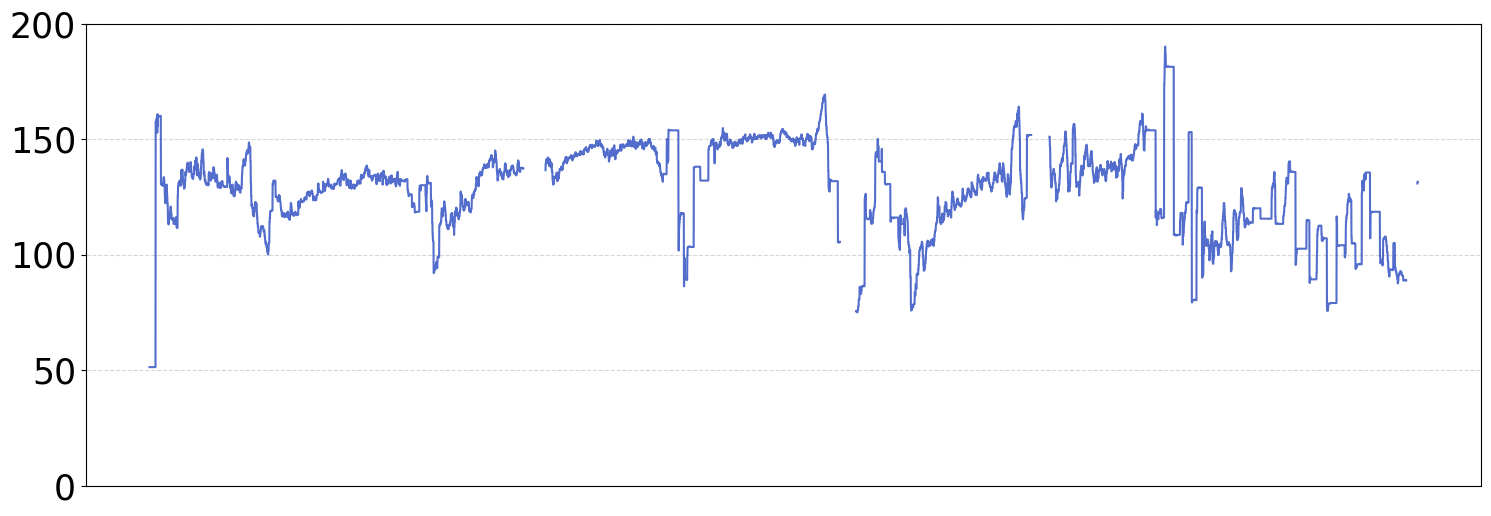

In [56]:
data.ctgs[1].plot_fhr()

In [ ]:
import numpy as np
import torch

def generar_fhr_prueba():
    np.random.seed(42)
    minutos = 10
    frecuencia = 4  
    total_puntos = minutos * 60 * frecuencia  # 2400 puntos
    
    _ = np.arange(total_puntos)
    fhr = 140 + np.random.normal(0, 1.5, total_puntos)
    
    fhr = np.convolve(fhr, np.ones(5)/5, mode='same')
    
    t_desacel1 = np.linspace(0, np.pi, 120)
    fhr[720:840] -= 25 * np.sin(t_desacel1)
    
    t_desacel2 = np.linspace(0, np.pi, 120)
    fhr[1680:1800] -= 35 * np.sin(t_desacel2)
    
    gap_inicio = 1720
    gap_fin = 1760
    
    fhr_con_gap = fhr.copy()
    fhr_con_gap[gap_inicio:gap_fin] = np.nan
    
    return fhr_con_gap, gap_inicio, gap_fin


fhr_con_gap, gap_inicio, gap_fin = generar_fhr_prueba()

print(f"Señal generada con éxito. Longitud total: {len(fhr_con_gap)} puntos (10 minutos a 4Hz).")
print(f"El hueco está entre los índices: {gap_inicio} y {gap_fin} (Duración: {gap_fin - gap_inicio} puntos).")

Señal generada con éxito. Longitud total: 2400 puntos (10 minutos a 4Hz).
El hueco está entre los índices: 1720 y 1760 (Duración: 40 puntos).


In [ ]:
FRECUENCIA = 4  
PUNTOS_POR_MINUTO = 1 * 30 * FRECUENCIA  

gap_longitud = gap_fin - gap_inicio


# 1. RECORTAR VENTANAS 
inicio_ventana_izq = max(0, gap_inicio - PUNTOS_POR_MINUTO)
contexto_izq = fhr_con_gap[inicio_ventana_izq:gap_inicio]

fin_ventana_der = min(len(fhr_con_gap), gap_fin + PUNTOS_POR_MINUTO)
contexto_der = fhr_con_gap[gap_fin:fin_ventana_der]


# ==========================================
# 2. PREDICCIÓN HACIA ADELANTE (DESDE LA IZQUIERDA)
# ==========================================
context_tensor_izq = torch.tensor(contexto_izq, dtype=torch.float32).unsqueeze(0)

print(f"Calculando desde el pasado (usando {len(contexto_izq)} puntos)...")
pred_izq = pipeline.predict(context_tensor_izq, prediction_length=gap_longitud)
low_izq, median_izq, high_izq = np.quantile(pred_izq[0].numpy(), [0.1, 0.5, 0.9], axis=0) #  mas info
relleno_izq = np.median(pred_izq[0].numpy(), axis=0)


# ==========================================
# 3. PREDICCIÓN HACIA ATRÁS (DESDE LA DERECHA)
# ==========================================
contexto_der_invertido = contexto_der[::-1].copy()

# Ahora PyTorch aceptará la matriz sin quejarse
context_tensor_der = torch.tensor(contexto_der_invertido, dtype=torch.float32).unsqueeze(0)

print(f"Calculando desde el futuro (usando {len(contexto_der)} puntos)...")
pred_der = pipeline.predict(context_tensor_der, prediction_length=gap_longitud)
low_der, median_der, high_der = np.quantile(pred_der[0].numpy(), [0.1, 0.5, 0.9], axis=0) #  mas info
relleno_der_invertido = np.median(pred_der[0].numpy(), axis=0)
relleno_der = relleno_der_invertido[::-1].copy() 

# ==========================================
# 4. FUSIÓN Y PARCHEO
# ==========================================
pesos_der = np.linspace(0, 1, gap_longitud)
pesos_izq = 1 - pesos_der
relleno_final = (relleno_izq * pesos_izq) + (relleno_der * pesos_der)

# Guardamos el resultado en la señal original
fhr_reparado = fhr_con_gap.copy()
fhr_reparado[gap_inicio:gap_fin] = relleno_final

print("\nFIIIIN!!")

Calculando desde el pasado (usando 120 puntos)...
Calculando desde el futuro (usando 120 puntos)...

FIIIIN!!


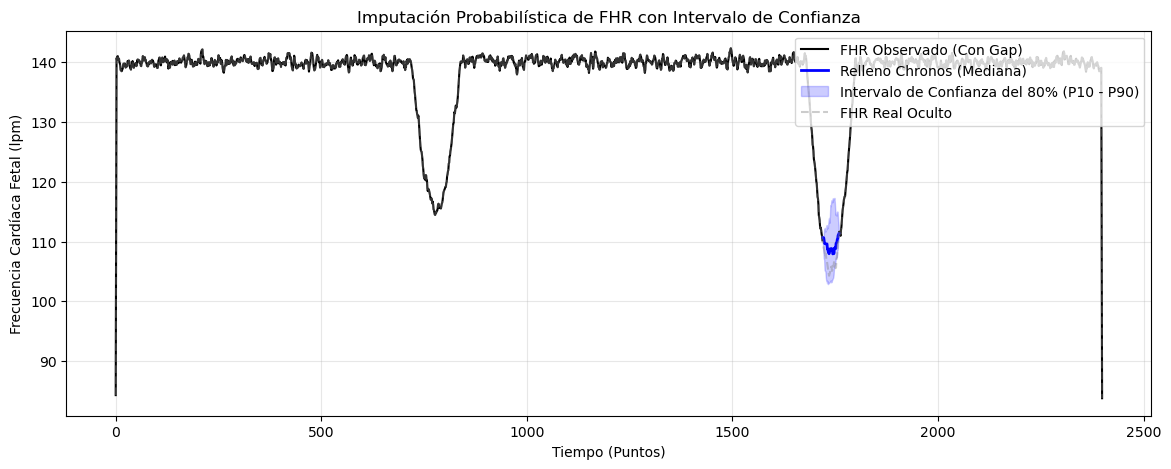

In [ ]:
low_izq, median_izq, high_izq = np.quantile(pred_izq[0].numpy(), [0.1, 0.5, 0.9], axis=0) #  mas info
low_der, median_der, high_der = np.quantile(pred_der[0].numpy(), [0.1, 0.5, 0.9], axis=0)

# invert el lado derecho
low_der = low_der[::-1].copy()
median_der = median_der[::-1].copy()
high_der = high_der[::-1].copy()

# 2. DEFINIR PESOS PARA LA FUSIÓN BIDIRECCIONAL
pesos_der = np.linspace(0, 1, gap_longitud)
pesos_izq = 1 - pesos_der

# 3. FUSIONAR LOS TRES NIVELES
# Fusionamos la mediana (el centro del relleno)
relleno_median = (median_izq * pesos_izq) + (median_der * pesos_der)

# Fusionamos los límites inferior y superior del intervalo de confianza
relleno_low = (low_izq * pesos_izq) + (low_der * pesos_der)
relleno_high = (high_izq * pesos_izq) + (high_der * pesos_der)

# 4. INSERTAR EN LA SEÑAL FINAL
fhr_reparado = fhr_con_gap.copy()
fhr_reparado[gap_inicio:gap_fin] = relleno_median


# ==========================================
# 5. CÓDIGO PARA GRAFICAR EL INTERVALO DE CONFIANZA
# ==========================================
plt.figure(figsize=(14, 5))

plt.plot(fhr_con_gap, color="black", linewidth=1.5, label="FHR Observado (Con Gap)")

eje_x_gap = np.arange(gap_inicio, gap_fin)

plt.plot(eje_x_gap, relleno_median, color="blue", linewidth=2, label="Relleno Chronos (Mediana)")

plt.fill_between(
    eje_x_gap, 
    relleno_low, 
    relleno_high, 
    color="blue", 
    alpha=0.2, 
    label="Intervalo de Confianza del 80% (P10 - P90)"
)

if 'fhr_real' in locals():
    plt.plot(fhr_reparado, color="gray", alpha=0.4, linestyle="--", label="FHR Real Oculto")

plt.title("Imputación Probabilística de FHR con Intervalo de Confianza")
plt.xlabel("Tiempo (Puntos)")
plt.ylabel("Frecuencia Cardíaca Fetal (lpm)")
plt.legend(loc="upper right")
plt.grid(True, alpha=0.3)
plt.show()

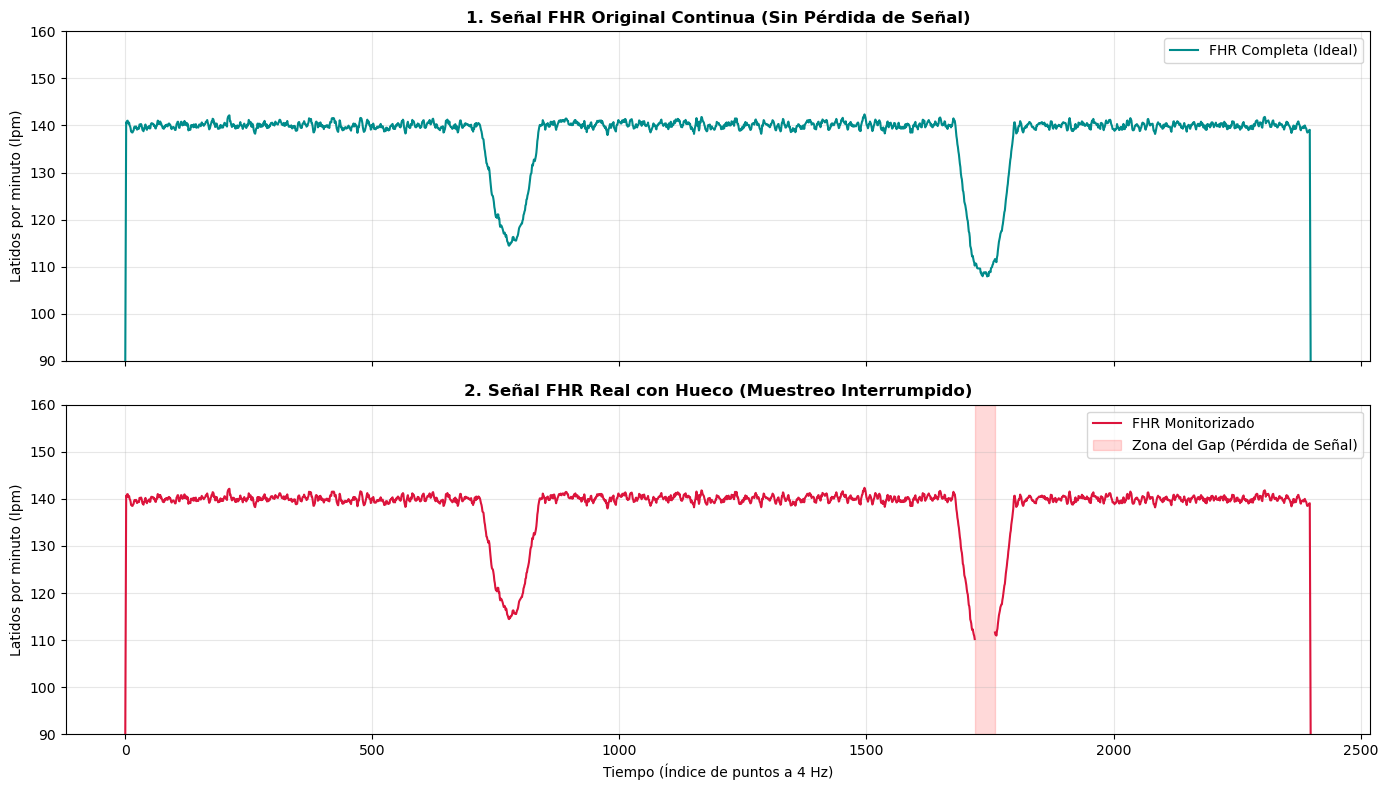

In [ ]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# --- Señal sin Gaps ---
ax1.plot(fhr_reparado, color="darkcyan", linewidth=1.5, label="FHR Completa (Ideal)")
ax1.set_title("1. Señal FHR Original Continua (Sin Pérdida de Señal)", fontsize=12, fontweight='bold')
ax1.set_ylabel("Latidos por minuto (lpm)")
ax1.set_ylim(90, 160)
ax1.grid(True, alpha=0.3)
ax1.legend(loc="upper right")

# ---  Señal con Gaps ---
ax2.plot(fhr_con_gap, color="crimson", linewidth=1.5, label="FHR Monitorizado")
ax2.axvspan(gap_inicio, gap_fin, color='red', alpha=0.15, label='Zona del Gap (Pérdida de Señal)')
ax2.set_title("2. Señal FHR Real con Hueco (Muestreo Interrumpido)", fontsize=12, fontweight='bold')
ax2.set_xlabel("Tiempo (Índice de puntos a 4 Hz)")
ax2.set_ylabel("Latidos por minuto (lpm)")
ax2.set_ylim(90, 160)
ax2.grid(True, alpha=0.3)
ax2.legend(loc="upper right")

plt.tight_layout()
plt.show()

In [7]:
from pathlib import Path
from pydantic import BaseModel
import commentjson

# ==========================================
# 1. OBJETOS DE PARÁMETROS (Moldes de datos)
# ==========================================
class DataLoaderConfig(BaseModel):
    dataset_path: str
    test_size: float
    shuffle: bool

class HyperparametersConfig(BaseModel):
    epochs: int
    learning_rate: float


# ==========================================
# 2. CLASE LECTORA (Responsabilidad Única)
# ==========================================
class ConfigReader:
    
    @staticmethod
    def load_config() -> dict:
        """Busca el archivo config.jsonc en la raíz y lo convierte en un diccionario."""
        # Localiza la raíz del proyecto sin importar desde dónde ejecutes el script
        # root_dir = Path(__file__).resolve().parent.parent
        config_path = "config.jsonc"
        
        # Abrimos el archivo de forma segura con codificación UTF-8
        with open(config_path, "r", encoding="utf-8") as file:
            # commentjson.load remueve los '//' y '/* */' automáticamente
            return commentjson.load(file)


# ==========================================
# 3. EJEMPLO DE EJECUCIÓN (Tu main.py)
# ==========================================
if __name__ == "__main__":
    try:
        # Paso A: Leer el archivo de disco y obtener el diccionario "limpio"
        dict_completo = ConfigReader.load_config()
        
        # Paso B: Extraer los bloques y empaquetarlos en sus clases correspondientes (Inyección)
        # config_datos = DataLoaderConfig(**dict_completo["data_loader"])
        # config_modelo = HyperparametersConfig(**dict_completo["model_hyperparameters"])
        
        # ¡Listo! Ya puedes usar tus variables de forma segura y con autocompletado
        print("¡Archivo configurado y cargado con éxito!")
        print(dict_completo.preprocess)
        # print(f"-> Ruta del dataset: {config_datos.dataset_path}")
        # print(f"-> ¿Barajar datos?: {config_datos.shuffle}")
        # print(f"-> Épocas de entrenamiento: {config_modelo.epochs}")
        
    except Exception as e:
        print(f"Error al cargar la configuración: {e}")

¡Archivo configurado y cargado con éxito!
Error al cargar la configuración: 'dict' object has no attribute 'preprocess'


In [13]:
# src/main.py
from pathlib import Path
import commentjson
import os

# 💡 AQUÍ IMPORTAS LAS CLASES DESDE TU OTRO FICHERO
from config_methods import AppConfig 

def load_config():
    # 💡 En Jupyter, usamos os.getcwd() en lugar de __file__
    root_dir = Path(os.getcwd())
    
    # Si tu notebook está dentro de la carpeta 'src/', sube un nivel:
    # root_dir = Path(os.getcwd()).parent
    
    config_path = "config.jsonc"
    
    with open(config_path, "r", encoding="utf-8") as file:
        raw_json_dict = commentjson.load(file) # 1. Sigue leyendo el diccionario plano
        objeto_configuracion = AppConfig(raw_json_dict) # 2. ¡NUEVO! Se lo pasamos a tu clase

        return objeto_configuracion # 3. Ahora devolvemos un OBJETO de tipo AppConfig

if __name__ == "__main__":
    # 1. Cargamos la configuración usando el otro fichero
    config = load_config()
    
    # 2. Accedes a tu variable limpiamente
    print(f"Ancho de banda cargado: {config.rules.incr_var_bandwidth}")
    
    # 3. Aquí pasarías esa configuración a tu clase de lógica (ejemplo):
    # selector_reglas = ValidadorClinico(config=config.rules)

Ancho de banda cargado: 25


In [ ]:
%load_ext autoreload
%autoreload 2

from models.df_ctg import DF_CTG

In [6]:
from models.df_ctg import DF_CTG
df = DF_CTG(config_file="config.jsonc")

In [8]:
df.read_ctgs_from_files()

NameError: name 'freq' is not defined